In [1]:
import sys
import os
project_root = os.path.abspath('..')
sys.path.append(project_root)
from src import AdversarialObjectDetection, add_noise, compare_detections, test_noise_defense_with_iou
from src import DenoisingAE
from src.noise_functions import add_noise
from src.iou_metrics import compare_detections_iou
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu126
True


In [3]:
#Load the denoiser model 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoiser = DenoisingAE().to(device)
denoiser.load_state_dict(torch.load("hgd_denoiser_cityscapes_best.pth", map_location=device))
denoiser.eval()

DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=

In [4]:
#Small test run for IoU evaluation of experiments
detector = AdversarialObjectDetection()
image_url = "..\\leftImg8bit\\test\\berlin\\berlin_000000_000019_leftImg8bit.png"
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 10},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'salt_and_pepper', 'density': 0.1},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]
PIPELINES = ["noise_only", "denoise_only", "noise_then_denoise"]

results = test_noise_defense_with_iou(
    detector=detector,
    image_path=image_url,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    num_iterations=5,
    denoiser=denoiser,
    pipelines=PIPELINES,
)

z:\Projects\Object-Detection\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
z:\Projects\Object-Detection\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model


In [5]:
import pprint 
for iou_type, res in results.items():
    print(f"\nResults for {iou_type.upper()}:")
    for t in res["noise_tests"]:
        cfg = t["noise_config"]
        print(
            f"{cfg['type']:>16} | {cfg.get('pipeline','?'):>16} | "
            f"clean_iou={t['clean_comparison']['average_iou']:.4f} | "
            f"adv_iou={t['adversarial_comparison']['average_iou']:.4f}"
        )


Results for STANDARD:
        gaussian |       noise_only | clean_iou=0.7303 | adv_iou=0.5543
        gaussian |     denoise_only | clean_iou=0.7528 | adv_iou=0.4335
        gaussian | noise_then_denoise | clean_iou=0.6653 | adv_iou=0.3779
 salt_and_pepper |       noise_only | clean_iou=0.2409 | adv_iou=0.2829
 salt_and_pepper | noise_then_denoise | clean_iou=0.3395 | adv_iou=0.2656
 salt_and_pepper |       noise_only | clean_iou=0.2444 | adv_iou=0.2125
 salt_and_pepper | noise_then_denoise | clean_iou=0.2097 | adv_iou=0.1720
         speckle |       noise_only | clean_iou=0.6637 | adv_iou=0.2576
         speckle | noise_then_denoise | clean_iou=0.6735 | adv_iou=0.3276
         poisson |       noise_only | clean_iou=0.7585 | adv_iou=0.5103
         poisson | noise_then_denoise | clean_iou=0.6925 | adv_iou=0.4117


In [6]:
#Using 300 testing images for distributions 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = AdversarialObjectDetection()
import glob
test_images = glob.glob("..\\leftImg8bit\\test\\berlin\\*.png")[:300]  
print(f"Found {len(test_images)} test images")

# Test parameters
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 5},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]

iou_types = ["standard", "giou"]

Loading model
Found 300 test images


In [7]:
#Reading in images and running the batch test with loops
#Returns a list of results dicts, one per image per iou_type, with keys:
# 'image', 'iou_type', 'clean_comparison', 'adversarial_comparison
def batch_test_with_loops(detector, image_paths, target_class, noise_configs,
                          iou_types, num_iterations=3, confidence_threshold=0.5,
                          denoiser=None, pipelines=None):

    all_results = []
    total_tests = len(image_paths)
    test_count = 0
    
    for image_path in image_paths:
        image_name = Path(image_path).name
        test_count += 1
        
        if test_count % 200 == 0:
            print(f"Processing image {test_count}/{total_tests}: {image_name}")
        
        try:
            original_image, adversarial_image, _ = detector.generate_adversarial_patch(
                image_path=image_path,
                target_class=target_class,
                num_iterations=num_iterations,
            )
            baseline_clean = detector.detect_objects(original_image)
            baseline_adversarial = detector.detect_objects(adversarial_image)
            
            precomputed_data = {
                'original_image': original_image,
                'adversarial_image': adversarial_image,
                'baseline_clean': baseline_clean,
                'baseline_adversarial': baseline_adversarial
            }
        except Exception as e:
            print(f"  ERROR generating adversarial image for {image_name}: {e}")
            for iou_type in iou_types:
                all_results.append({'image': image_name, 'iou_type': iou_type, 'error': str(e)})
            continue
        
        try:
            
            results_dict = test_noise_defense_with_iou(
                detector=detector,
                image_path=image_path, 
                target_class=target_class,
                noise_configs=noise_configs,
                num_iterations=num_iterations,
                iou_types=iou_types,
                confidence_threshold=confidence_threshold,
                denoiser=denoiser,
                pipelines=pipelines,
                precomputed_data=precomputed_data)
            
            
            for iou_type, res in results_dict.items():
                res['image'] = image_name
                res['iou_type'] = iou_type
                all_results.append(res)
                
        except Exception as e:
            print(f"  ERROR testing noise on {image_name}: {e}")
            for iou_type in iou_types:
                all_results.append({'image': image_name, 'iou_type': iou_type, 'error': str(e)})
    
    return all_results

In [8]:
#Ploting 2D distribution of clean vs adversarial Iou Scores
def plot_2d_distributions(all_results, num_iterations=5, confidence_threshold=0.5, output_dir='results'):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    
    def _split_label(label: str):
        base_label, pipeline = (label.split("__", 1) + [""])[:2]
        return base_label, pipeline
    
    def _display_base_label(base_label: str) -> str:
        if base_label == "denoise_only":
            return "Denoise only"
        if base_label.startswith("gaussian_std"):
            var_val = int(float(base_label.replace("gaussian_std", ""))**2)
            return f"VAR={var_val}"
        if base_label.startswith("salt_pepper_"):
            return f"Density={base_label.replace('salt_pepper_', '')}"
        if base_label.startswith("speckle_"):
            return f"Intensity={base_label.replace('speckle_', '')}"
        if base_label.startswith("poisson_"):
            return f"Scale={base_label.replace('poisson_', '')}"
        return base_label.replace("_", " ")

    noise_type = None
    for result in all_results:
        if 'error' in result or not result.get('noise_tests'):
            continue
        for t in result['noise_tests']:
            cfg = t.get('noise_config', {})
            if cfg.get('pipeline') != 'denoise_only':
                noise_type = cfg.get('type')
                if noise_type: break
        if noise_type: break
    if noise_type is None: noise_type = 'unknown'
    
    base_dir = os.path.join('..', output_dir, noise_type)
    config_dir = os.path.join(base_dir, f'conf_{confidence_threshold}_iter_{num_iterations}')
    os.makedirs(config_dir, exist_ok=True)
    
    iou_type_data = {}
    for result in all_results:
        if 'error' in result or not result.get('noise_tests'): continue
        iou_type = result.get('iou_type', 'standard')
        if iou_type not in iou_type_data: iou_type_data[iou_type] = {}
        
        seen_denoise = False
        for test in result['noise_tests']:
            cfg = test.get('noise_config', {})
            pipeline = cfg.get('pipeline', 'noise_only')
            if pipeline == 'denoise_only':
                if seen_denoise: continue
                seen_denoise = True
                base_label = 'denoise_only'
            else:
                nt = cfg.get('type', 'unknown')
                if nt == 'gaussian': base_label = f"gaussian_std{cfg['std']}"
                elif nt == 'salt_and_pepper': base_label = f"salt_pepper_{cfg['density']}"
                elif nt == 'speckle': base_label = f"speckle_{cfg['intensity']}"
                elif nt == 'poisson': base_label = f"poisson_{cfg['scale']}"
                else: base_label = str(nt)
                
            label = f"{base_label}__{pipeline}"
            if label not in iou_type_data[iou_type]:
                iou_type_data[iou_type][label] = {'clean': [], 'adv': []}
            
            iou_type_data[iou_type][label]['clean'].append(test['clean_comparison']['average_iou'])
            iou_type_data[iou_type][label]['adv'].append(test['adversarial_comparison']['average_iou'])
            
    for iou_type, noise_data in iou_type_data.items():
        for noise_label, values in noise_data.items():
            base_label, pipeline = _split_label(noise_label)
            display_title = f"{_display_base_label(base_label)} - {pipeline}"
            
            fig, ax = plt.subplots(figsize=(10, 6))
            bins = np.linspace(0, 1, 21)
            
            ax.hist(values['clean'], bins=bins, alpha=0.5, label='Clean', color='dodgerblue', edgecolor='black')
            ax.hist(values['adv'], bins=bins, alpha=0.5, label='Adversarial', color='orangered', edgecolor='black')
            
            ax.set_title(f"{iou_type.upper()} Distribution: {display_title}", fontsize=14)
            ax.set_xlabel("IoU Score", fontsize=12)
            ax.set_ylabel("Count", fontsize=12)
            ax.grid(axis='y', alpha=0.3)
            
            safe_label = noise_label.replace('.', '_')
            plt.savefig(os.path.join(config_dir, f'dist_{iou_type}_{safe_label}.png'))
            plt

In [9]:
#Calulates detection accuracy byt sweeping through thresholds and count correct detections 
def calculate_detection_accuracy_at_thresholds(all_results, iou_thresholds=np.arange(0.1, 1.0, 0.1)):
    iou_type_results = {}
    
    for result in all_results:
        if 'error' in result:
            continue
        if not result.get('noise_tests'):
            continue
        iou_type = result.get('iou_type', 'standard')
        if iou_type not in iou_type_results:
            iou_type_results[iou_type] = {}
        
        seen_denoise_only = False
        for noise_test in result['noise_tests']:
            noise_config = noise_test.get('noise_config', {})
            pipeline = noise_config.get('pipeline', 'noise_only')
            noise_type = noise_config.get('type', 'unknown')
            
            if pipeline == 'denoise_only':
                if seen_denoise_only:
                    continue
                seen_denoise_only = True
                base_label = 'denoise_only'
            else:
                if noise_type == 'gaussian':
                    base_label = f"gaussian_var{int(noise_config['std']**2)}"
                elif noise_type == 'salt_and_pepper':
                    base_label = f"salt_pepper_{noise_config['density']}"
                elif noise_type == 'speckle':
                    base_label = f"speckle_{noise_config['intensity']}"
                elif noise_type == 'poisson':
                    base_label = f"poisson_{noise_config['scale']}"
                else:
                    base_label = str(noise_type)
            
            noise_label = f"{base_label}__{pipeline}"
            if noise_label not in iou_type_results[iou_type]:
                iou_type_results[iou_type][noise_label] = {'clean_ious': [], 'adversarial_ious': []}
            
            clean_iou = noise_test['clean_comparison']['average_iou']
            adv_iou = noise_test['adversarial_comparison']['average_iou']
            iou_type_results[iou_type][noise_label]['clean_ious'].append(clean_iou)
            iou_type_results[iou_type][noise_label]['adversarial_ious'].append(adv_iou)
    
    accuracy_results = {}
    for iou_type, noise_data in iou_type_results.items():
        accuracy_results[iou_type] = {}
        for noise_label, data in noise_data.items():
            clean_ious = np.array(data['clean_ious'])
            adv_ious = np.array(data['adversarial_ious'])
            
            accuracy_results[iou_type][noise_label] = {
                'thresholds': iou_thresholds.tolist(),
                'accuracy': []
            }
            
            for threshold in iou_thresholds:
                clean_correct = np.sum(clean_ious >= threshold)
                adv_correct = np.sum(adv_ious < threshold)
                total = len(clean_ious) + len(adv_ious)
                accuracy = (clean_correct + adv_correct) / total if total > 0 else 0
                accuracy_results[iou_type][noise_label]['accuracy'].append(accuracy)
    
    return accuracy_results

In [10]:
#Plots the accuracyt rates vs thresholds for each nooise type and pipeline
def plot_detection_accuracy_vs_threshold(accuracy_results, output_dir='results', 
                                         num_iterations=5, confidence_threshold=0.5):
    import os
    import matplotlib.pyplot as plt
    import numpy as np
    
    def _split_label(label: str):
        base_label, pipeline = (label.split("__", 1) + [""])[:2]
        return base_label, pipeline
    
    def _infer_noise_type(noise_labels):
        for lbl in noise_labels:
            base_label, _ = _split_label(lbl)
            if base_label == 'denoise_only': continue
            if base_label.startswith('gaussian_'): return 'gaussian'
            if base_label.startswith('salt_pepper'): return 'salt_and_pepper'
            if base_label.startswith('speckle'): return 'speckle'
            if base_label.startswith('poisson'): return 'poisson'
        return 'unknown'
    
    summary_data = []
    
    for iou_type, noise_data in accuracy_results.items():
        noise_type = _infer_noise_type(list(noise_data.keys()))
        base_dir = os.path.join('..', output_dir, noise_type)
        config_dir = os.path.join(base_dir, f'conf_{confidence_threshold}_iter_{num_iterations}')
        os.makedirs(config_dir, exist_ok=True)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        print(f"--- Max Accuracy for {iou_type.upper()} ({noise_type}) ---")
        
        for noise_label, data in noise_data.items():
            thresholds = data['thresholds']
            acc_array = np.array(data['accuracy'])
            max_acc = np.max(acc_array)
            best_thresh = thresholds[np.argmax(acc_array)]
            
            base_label, pipeline = _split_label(noise_label)
            if base_label == 'denoise_only': display_base = 'Denoise only'
            elif base_label.startswith('gaussian_var'): display_base = f"Gaussian VAR={base_label.split('var', 1)[1]}"
            elif base_label.startswith('salt_pepper'): display_base = f"Salt & Pepper D={base_label.split('_')[-1]}"
            elif base_label.startswith('speckle'): display_base = f"Speckle I={base_label.split('_')[-1]}"
            elif base_label.startswith('poisson'): display_base = f"Poisson S={base_label.split('_')[-1]}"
            else: display_base = base_label.replace('_', ' ').title()
            
            display_label = f"{display_base} ({pipeline})" if pipeline else display_base
            print(f"  {display_label}: {max_acc:.4f} @ Threshold {best_thresh:.2f}")
            
            summary_data.append({
                'Noise Type': noise_type.title(),
                'IoU Metric': iou_type.upper(),
                'Configuration': display_label,
                'Max Accuracy': max_acc,
                'Optimal Threshold': best_thresh
            })
            
            ax.plot(thresholds, acc_array, label=display_label, linestyle='-', marker='.', markersize=4, linewidth=2)
        
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Random Baseline (50%)')
        ax.set_xlabel('IoU Threshold', fontsize=14, fontweight='bold')
        ax.set_ylabel('Detection Accuracy', fontsize=14, fontweight='bold')
        ax.set_title(f'{iou_type.upper()} - Adversarial Detection Accuracy vs IoU Threshold', fontsize=15, pad=20)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)
        ax.set_xlim(thresholds[0], thresholds[-1])
        ax.set_ylim(0, 1.05)
        
        plt.savefig(os.path.join(config_dir, f'detection_accuracy_{iou_type}.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)
        
    return summary_data

In [11]:
#Main function to run the batch test and generate plots
def batch_test_with_plots(num_iterations=3, confidence_threshold=0.5, test_images=None, target_class=20, noise_configs=None, iou_types=None, denoiser=None, pipelines=None):
    detector = AdversarialObjectDetection()
    
    x_all = batch_test_with_loops(
        detector=detector,
        image_paths=test_images,
        target_class=target_class,
        noise_configs=noise_configs,
        iou_types=iou_types,
        num_iterations=num_iterations,
        confidence_threshold=confidence_threshold,
        denoiser=denoiser,
        pipelines=pipelines
    )
    

    unique_noise_types = set()
    for cfg in noise_configs:
        unique_noise_types.add(cfg.get('type'))
        
    for current_noise in unique_noise_types:
        print(f"\n============= Generating Plots/Metrics for {current_noise.upper()} =============")

        filtered_x = []
        for result in x_all:
            if 'error' in result:
                filtered_x.append(result)
                continue
                
            filtered_tests = []
            for test in result.get('noise_tests', []):
                cfg = test.get('noise_config', {})
                pipeline = cfg.get('pipeline', '')
                
                if cfg.get('type') == current_noise:
                    filtered_tests.append(test)
                elif pipeline == 'denoise_only':
                    filtered_tests.append(test)
                    
            filtered_res = dict(result)
            filtered_res['noise_tests'] = filtered_tests
            filtered_x.append(filtered_res)


        plot_2d_distributions(filtered_x, num_iterations=num_iterations, confidence_threshold=confidence_threshold)

        accuracy_results = calculate_detection_accuracy_at_thresholds(
            filtered_x, 
            iou_thresholds=np.arange(0.01, 1.01, 0.01)
        )
        plot_detection_accuracy_vs_threshold(
            accuracy_results, 
            num_iterations=num_iterations, 
            confidence_threshold=confidence_threshold
        )

In [12]:
print(torch.cuda.is_available())

True


Loading model
Processing image 200/300: berlin_000199_000019_leftImg8bit.png

============= Generating Plots/Metrics for POISSON =============


C:\Users\victo\AppData\Local\Temp\ipykernel_25924\3363272659.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


--- Max Accuracy for STANDARD (poisson) ---
  Poisson S=0.1 (noise_only): 0.7183 @ Threshold 0.44
  Denoise only (denoise_only): 0.9000 @ Threshold 0.58
  Poisson S=0.1 (noise_then_denoise): 0.7067 @ Threshold 0.43
  Poisson S=0.3 (noise_only): 0.8400 @ Threshold 0.52
  Poisson S=0.3 (noise_then_denoise): 0.8450 @ Threshold 0.54
  Poisson S=0.9 (noise_only): 0.8950 @ Threshold 0.59
  Poisson S=0.9 (noise_then_denoise): 0.8900 @ Threshold 0.58
--- Max Accuracy for GIOU (poisson) ---
  Poisson S=0.1 (noise_only): 0.7183 @ Threshold 0.43
  Denoise only (denoise_only): 0.9033 @ Threshold 0.58
  Poisson S=0.1 (noise_then_denoise): 0.7133 @ Threshold 0.41
  Poisson S=0.3 (noise_only): 0.8400 @ Threshold 0.50
  Poisson S=0.3 (noise_then_denoise): 0.8483 @ Threshold 0.54
  Poisson S=0.9 (noise_only): 0.8967 @ Threshold 0.59
  Poisson S=0.9 (noise_then_denoise): 0.8967 @ Threshold 0.57
--- Max Accuracy for DIOU (poisson) ---
  Poisson S=0.1 (noise_only): 0.7233 @ Threshold 0.41
  Denoise only (

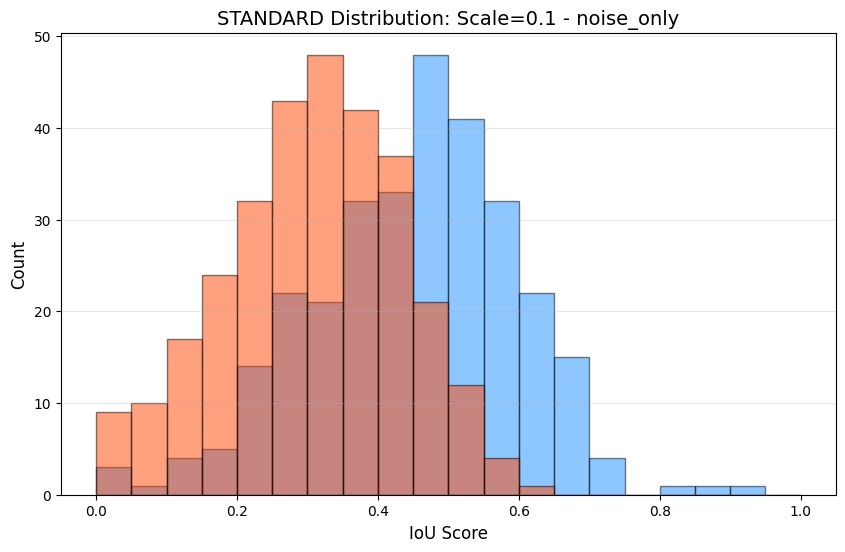

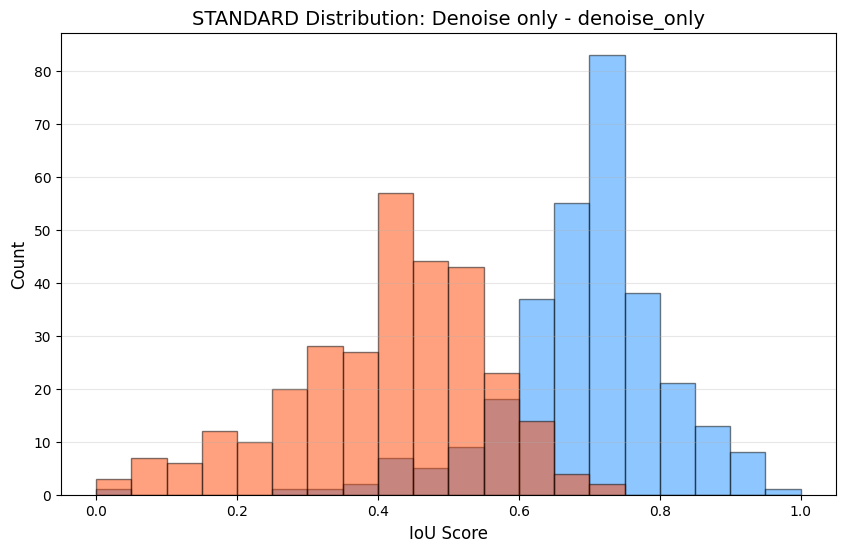

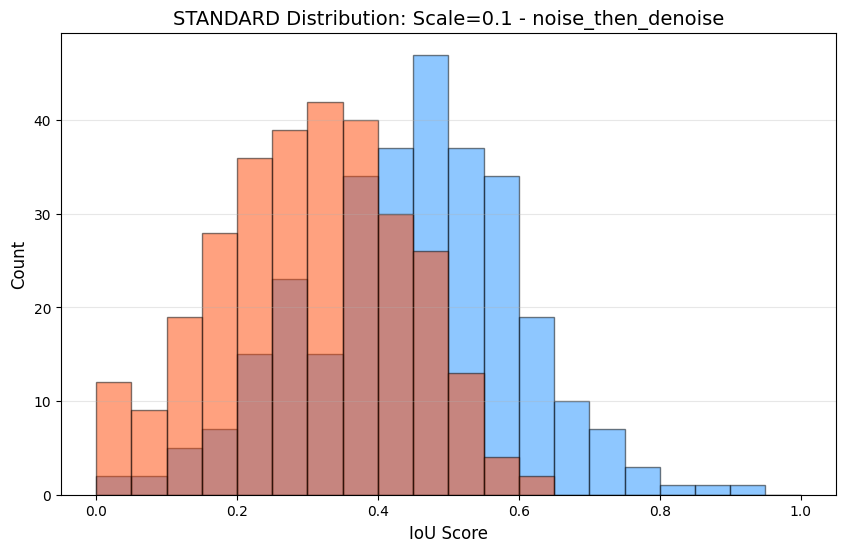

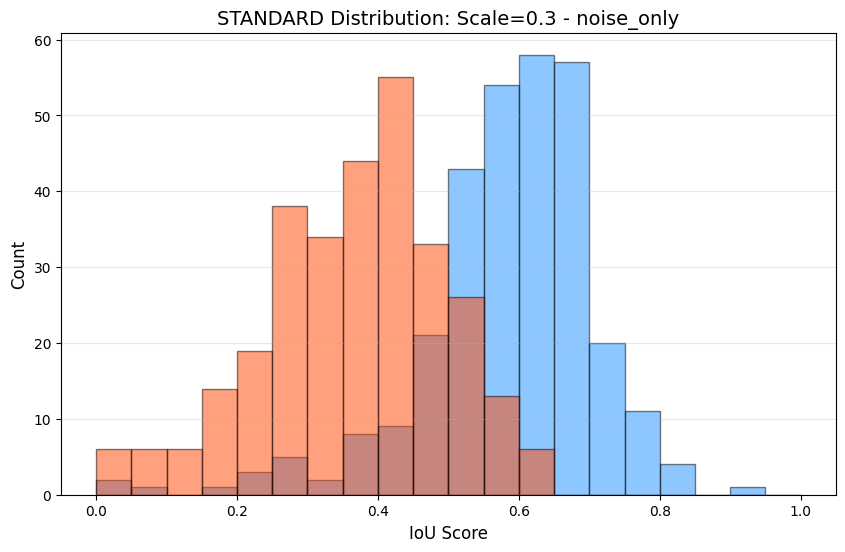

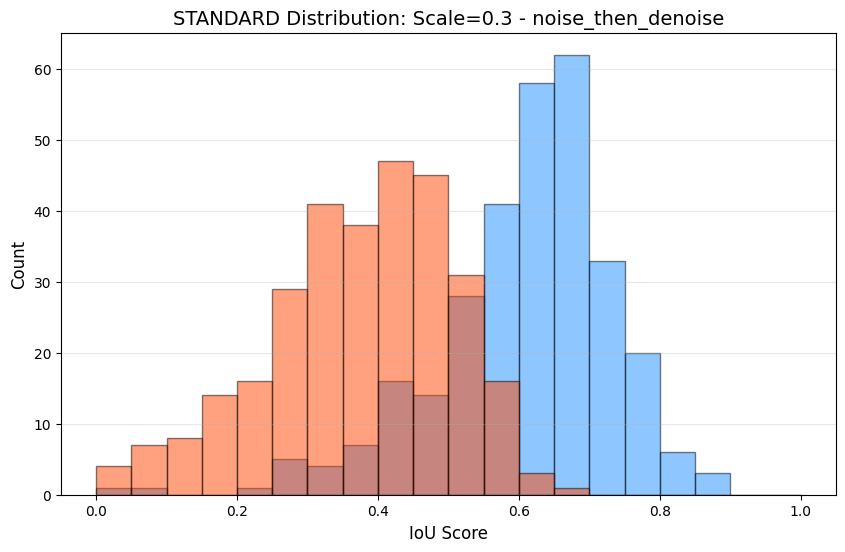

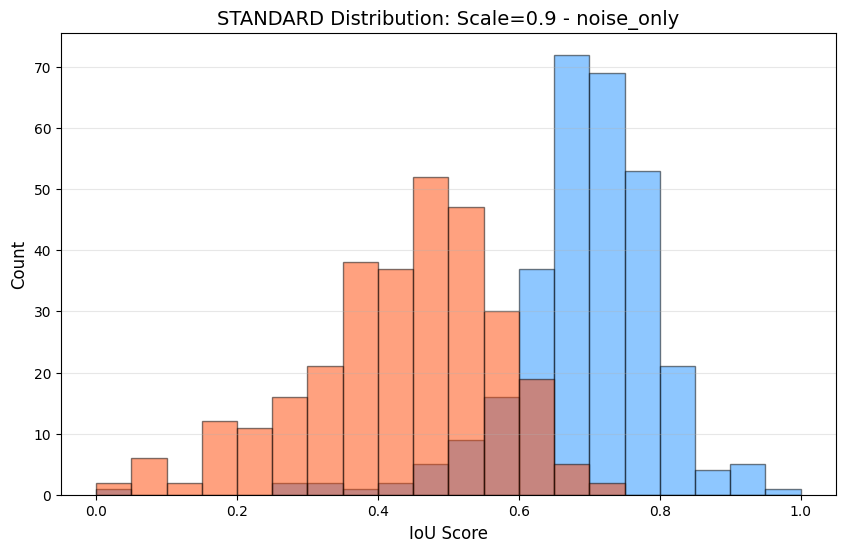

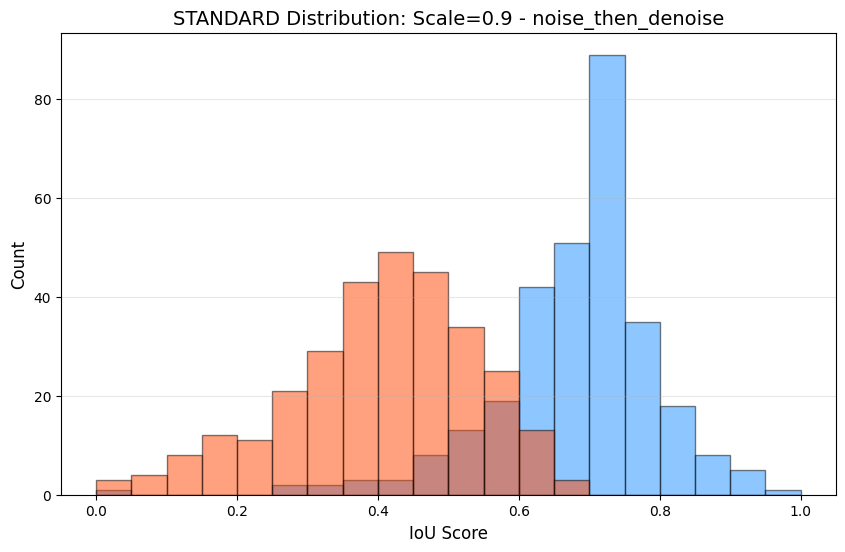

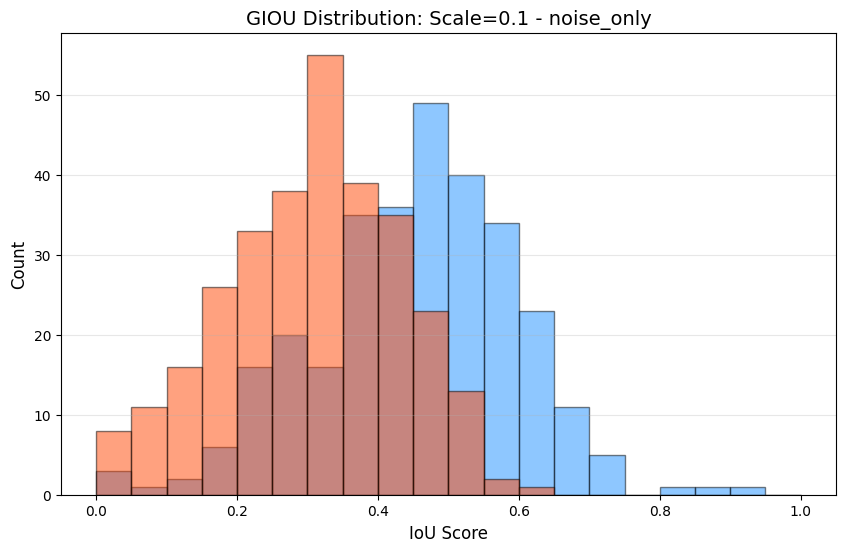

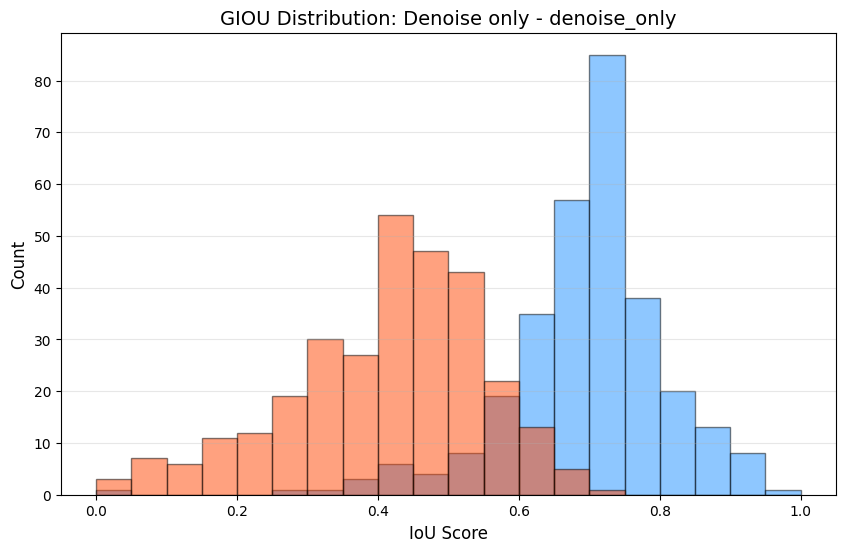

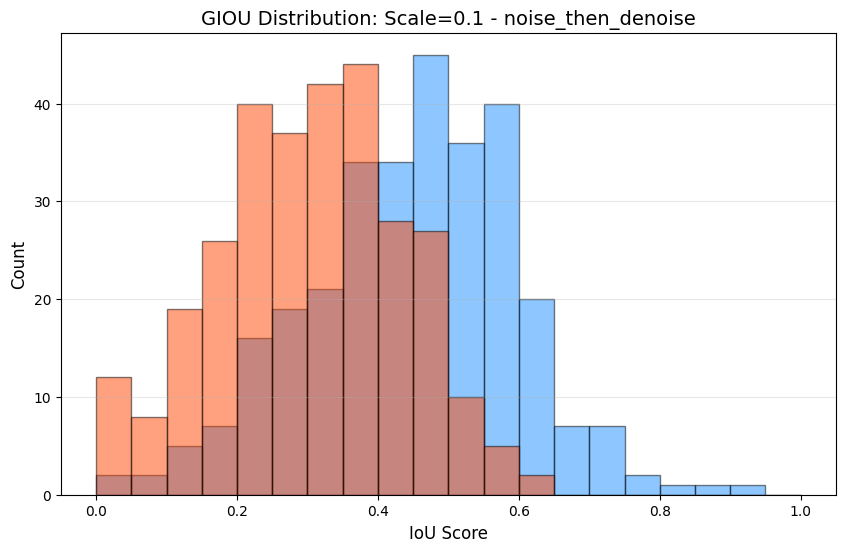

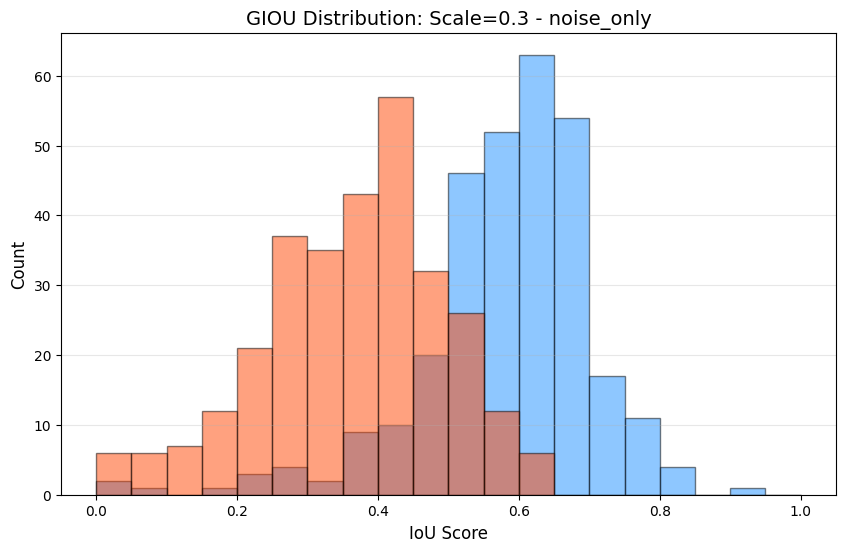

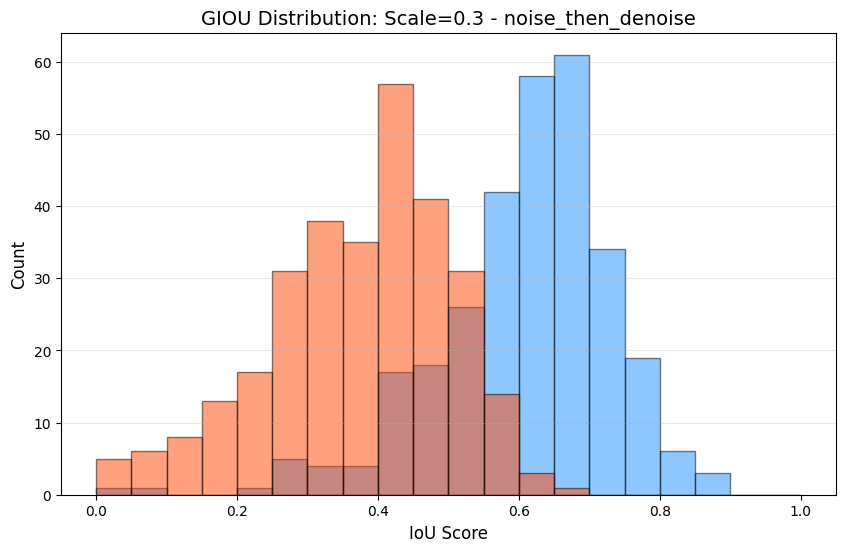

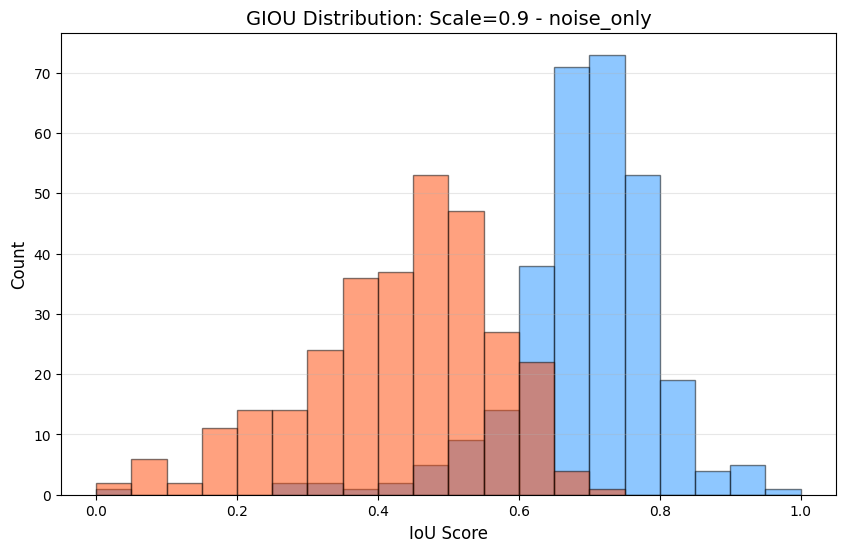

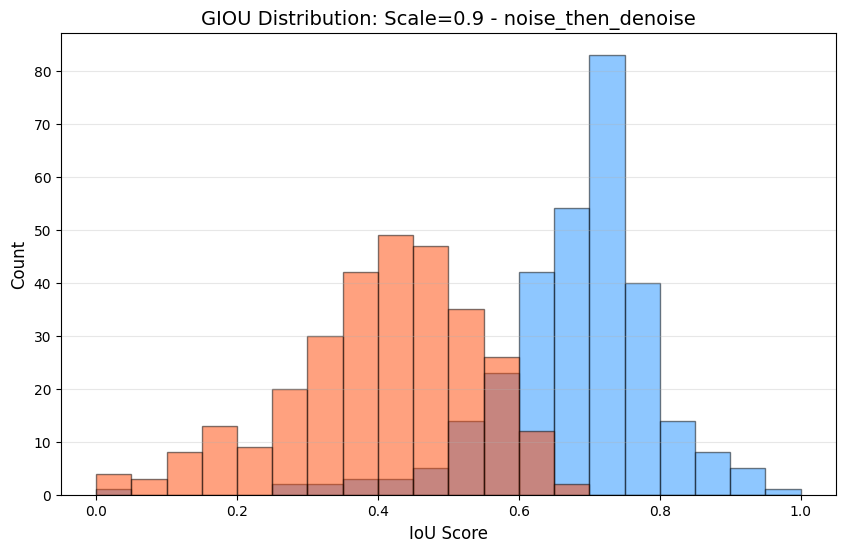

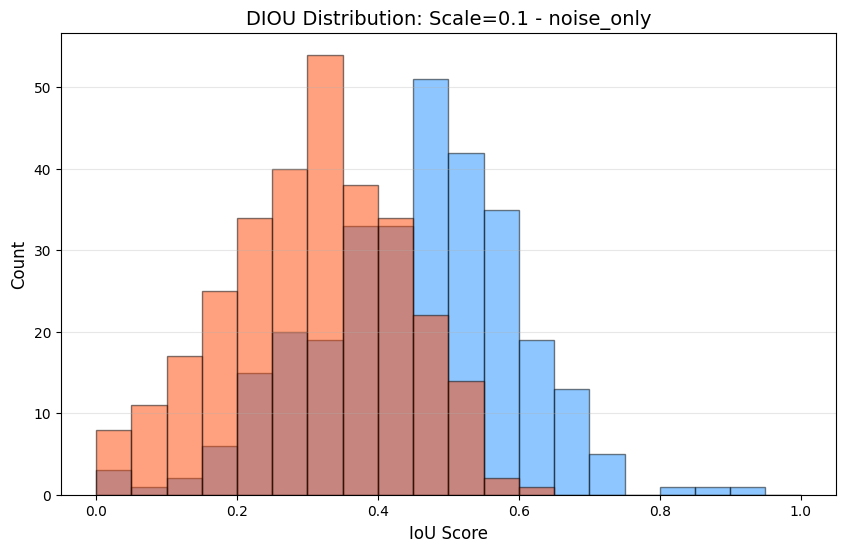

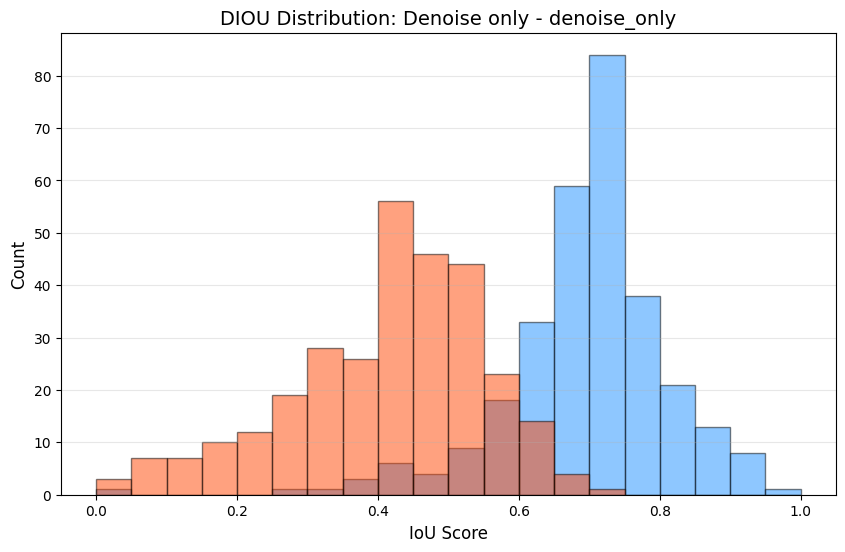

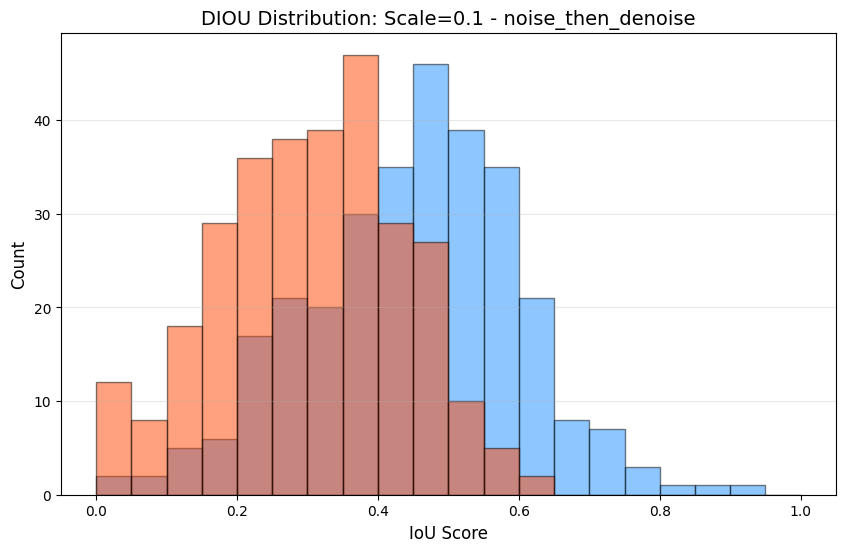

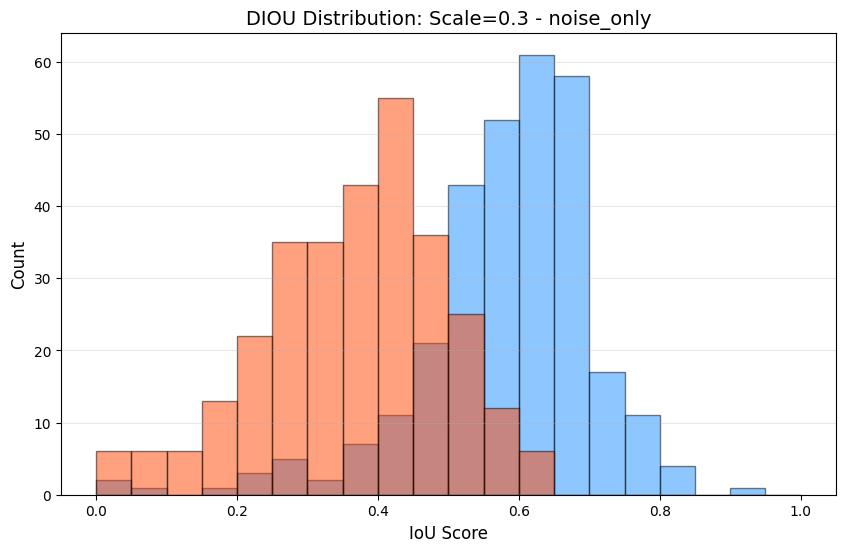

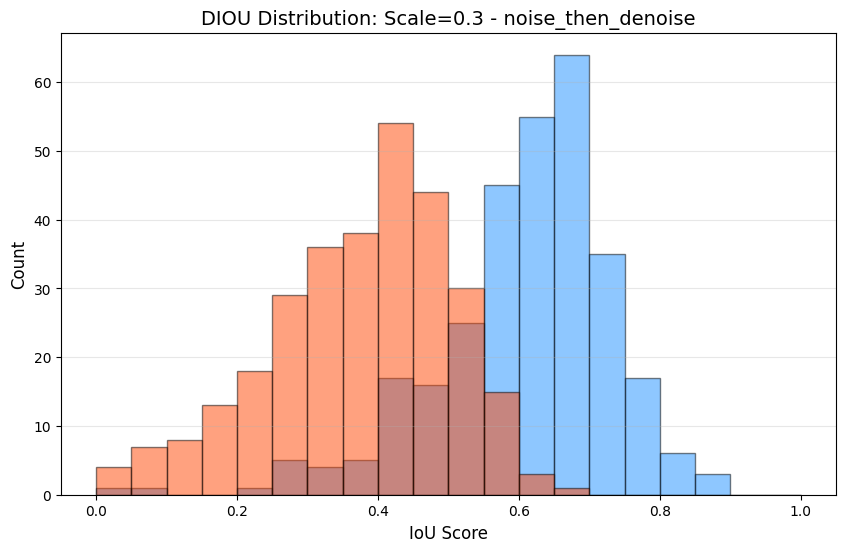

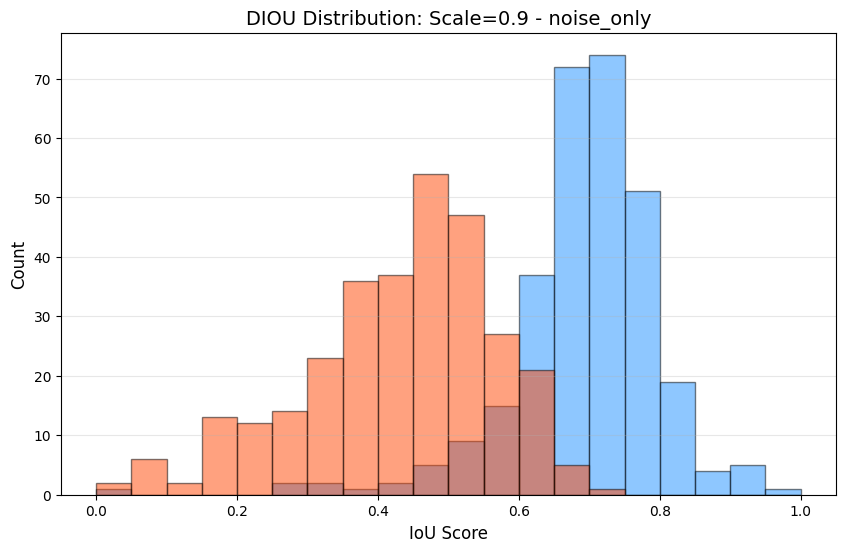

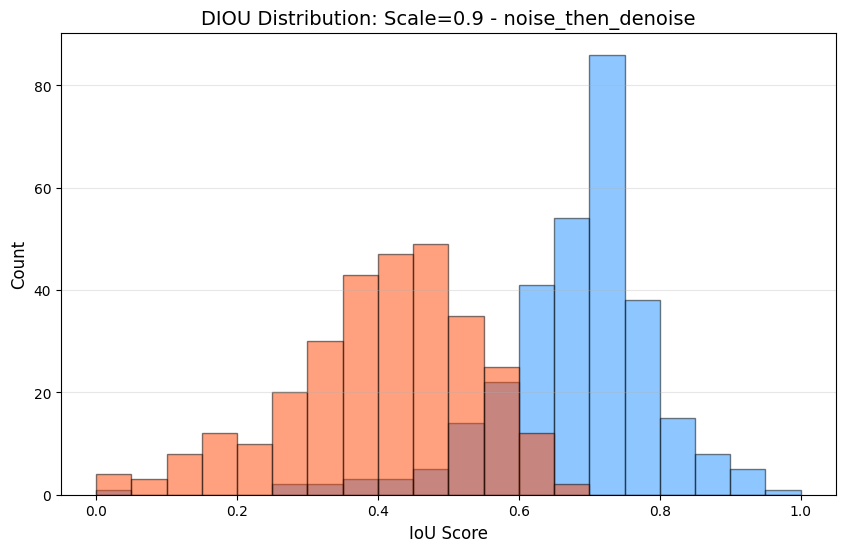

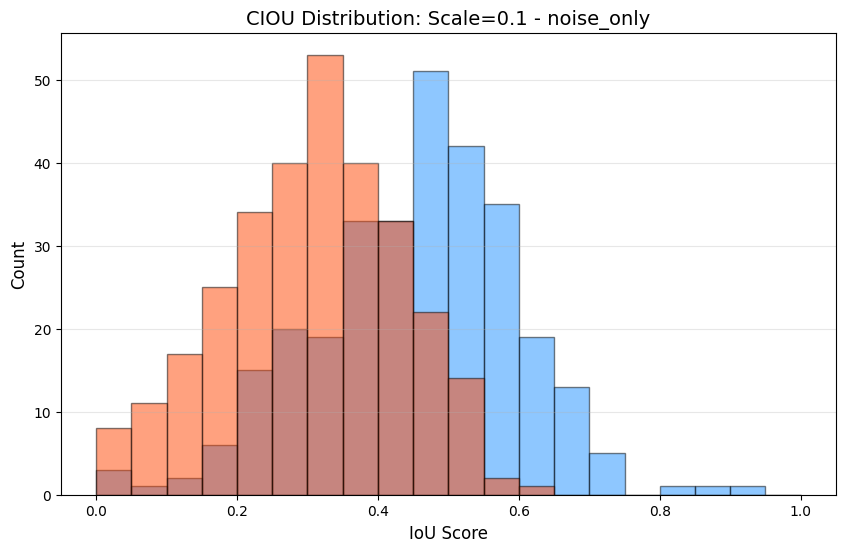

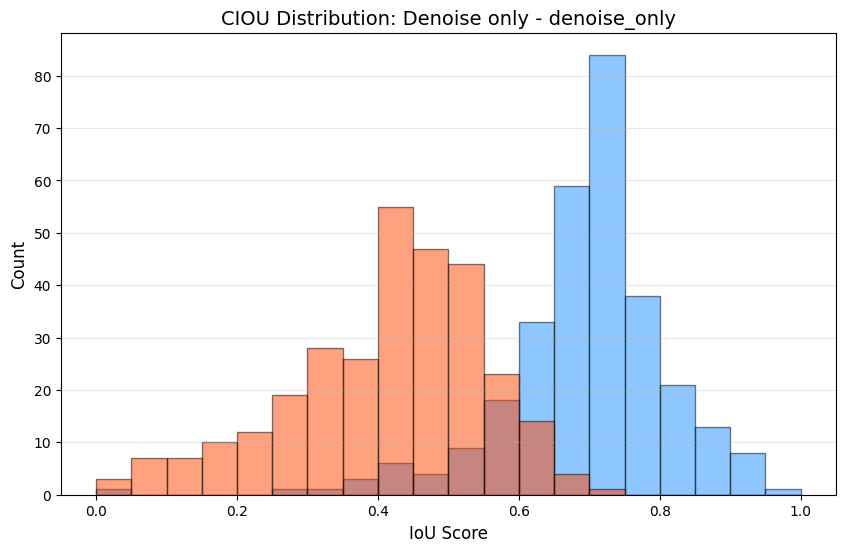

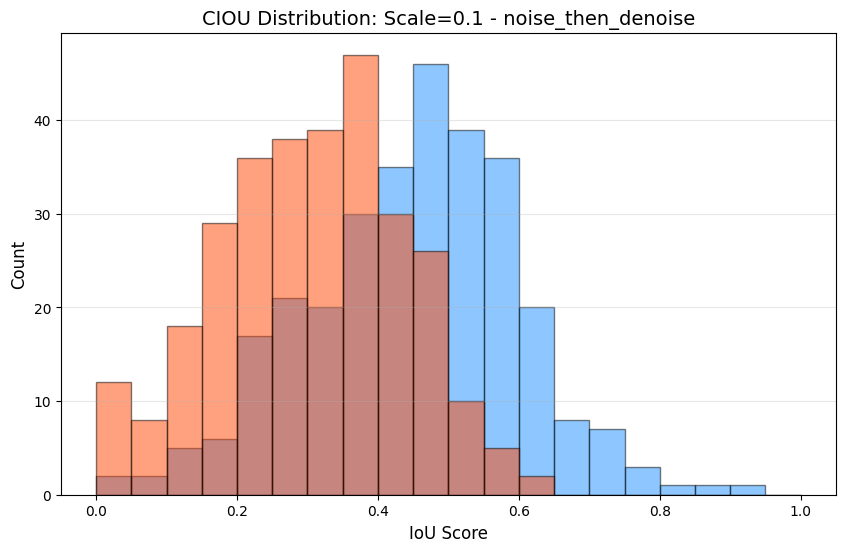

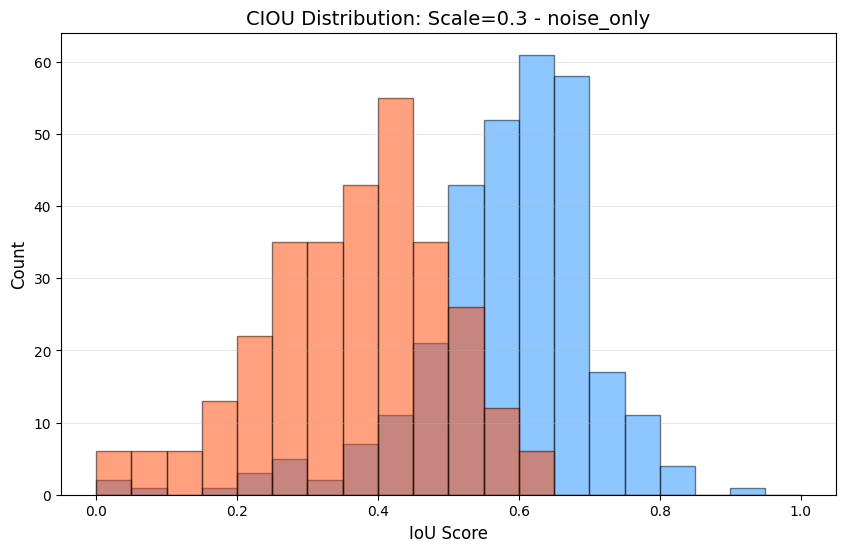

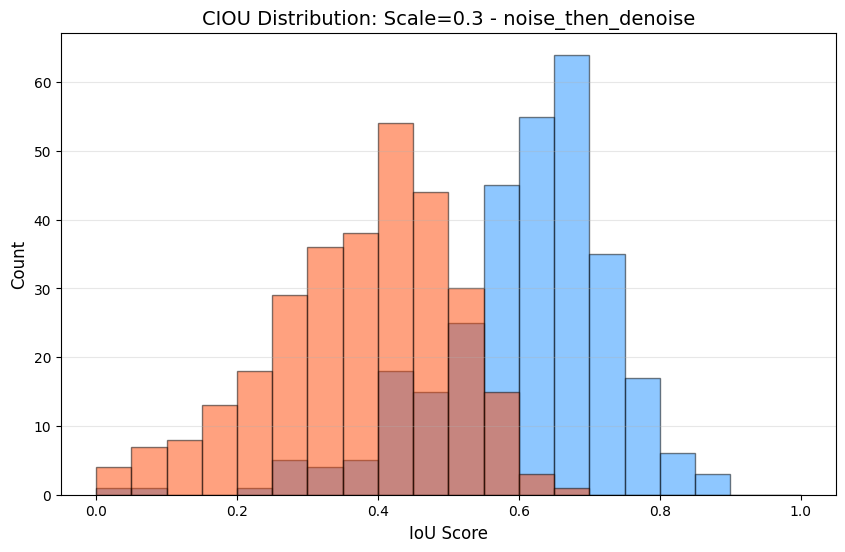

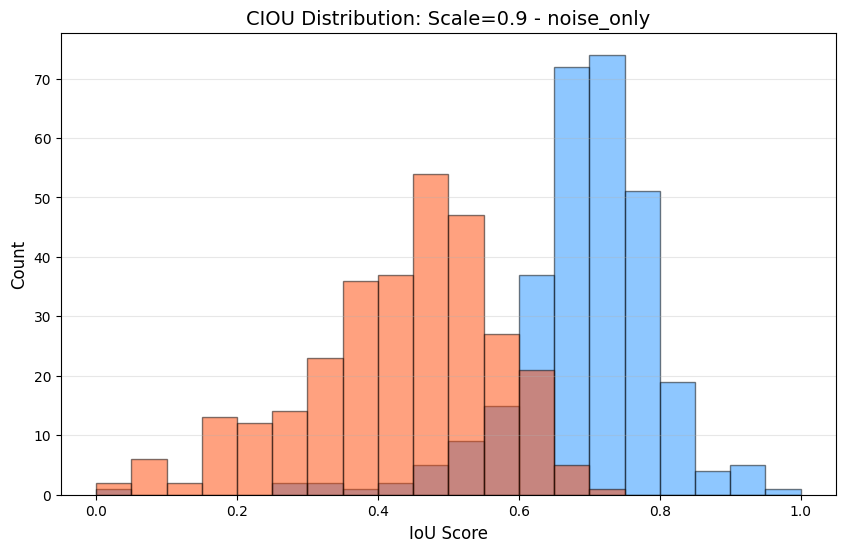

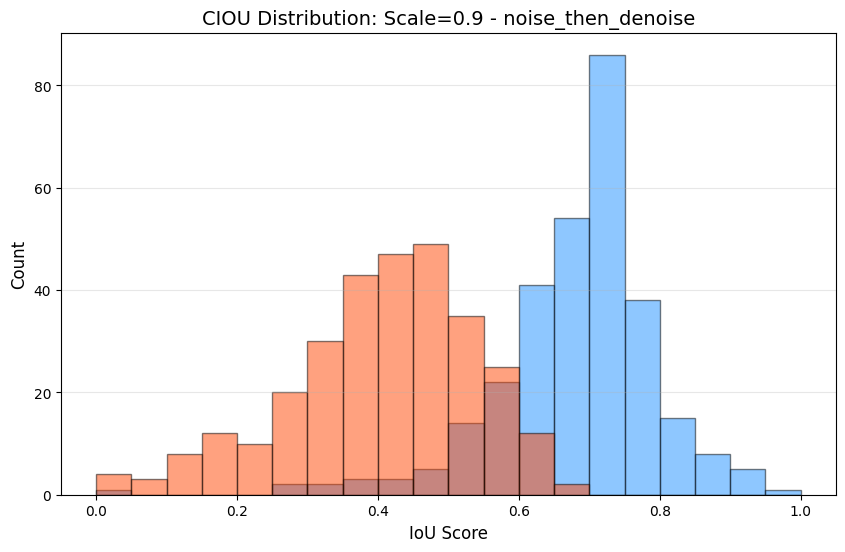

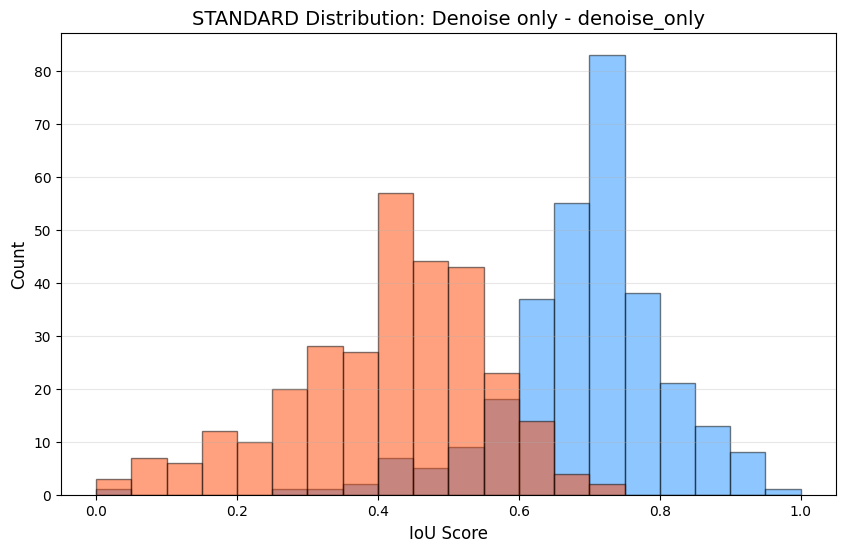

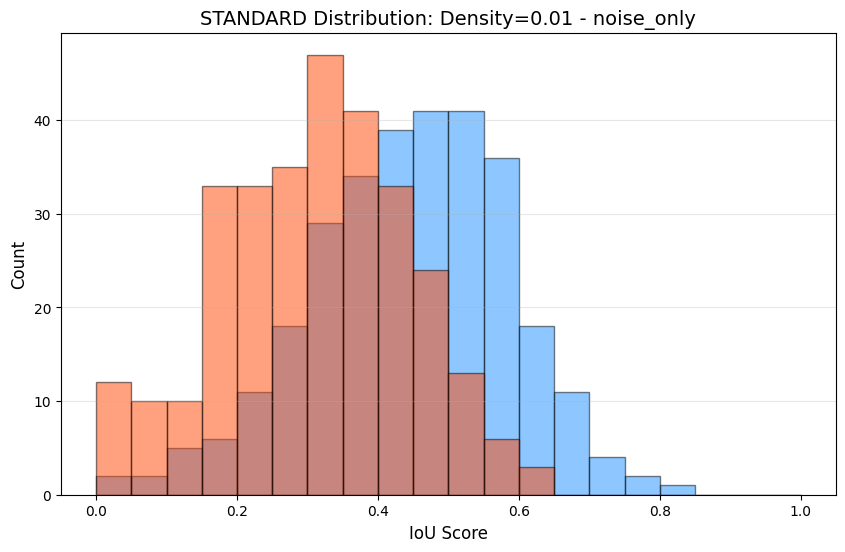

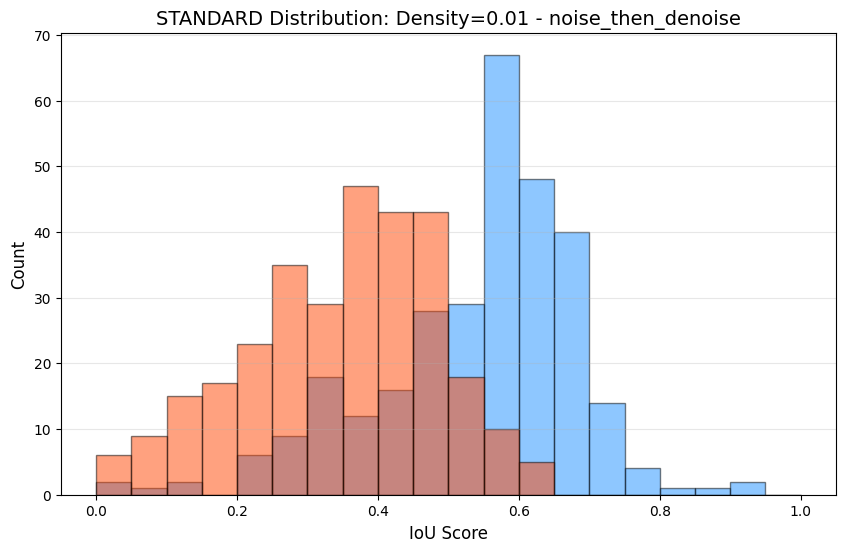

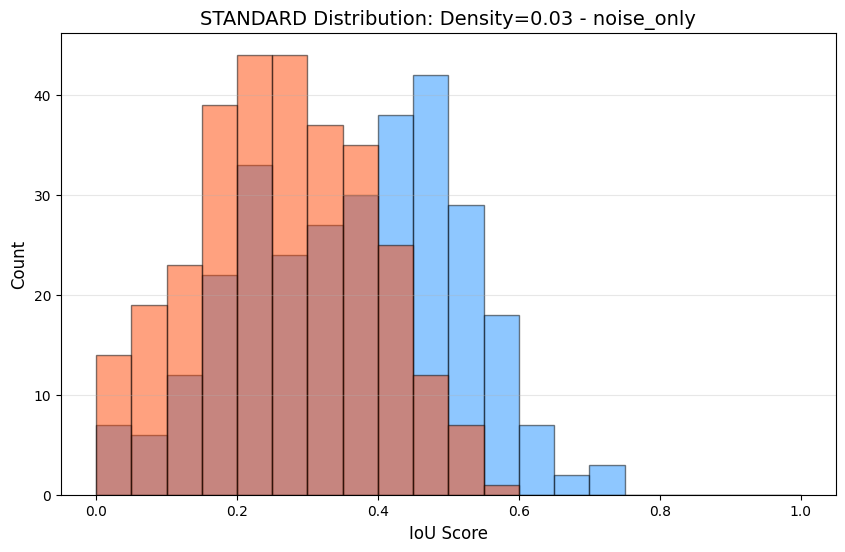

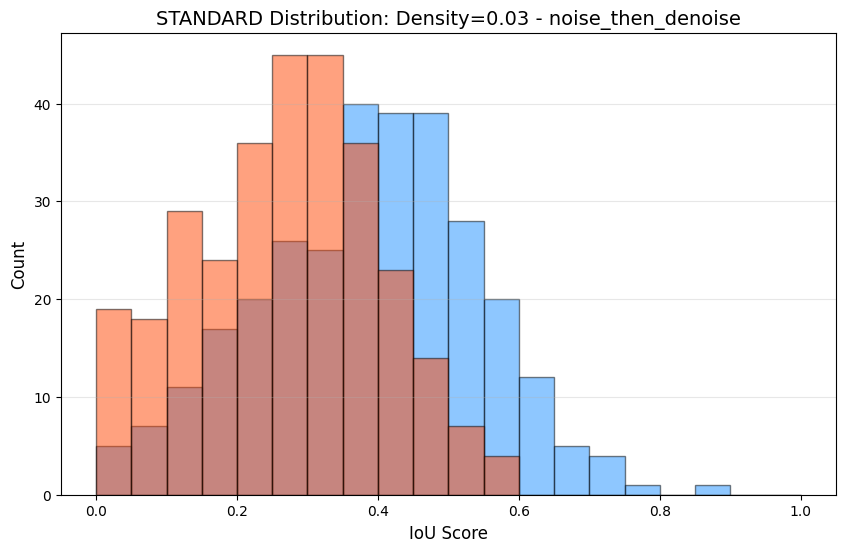

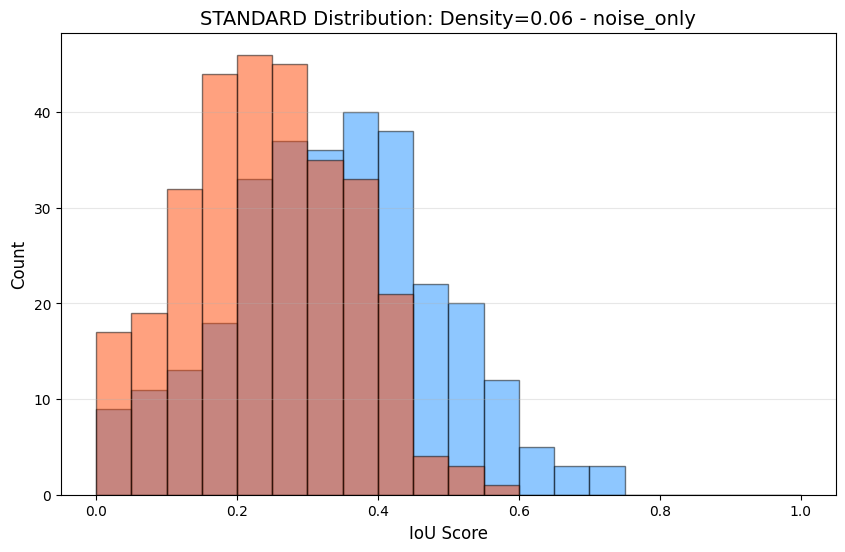

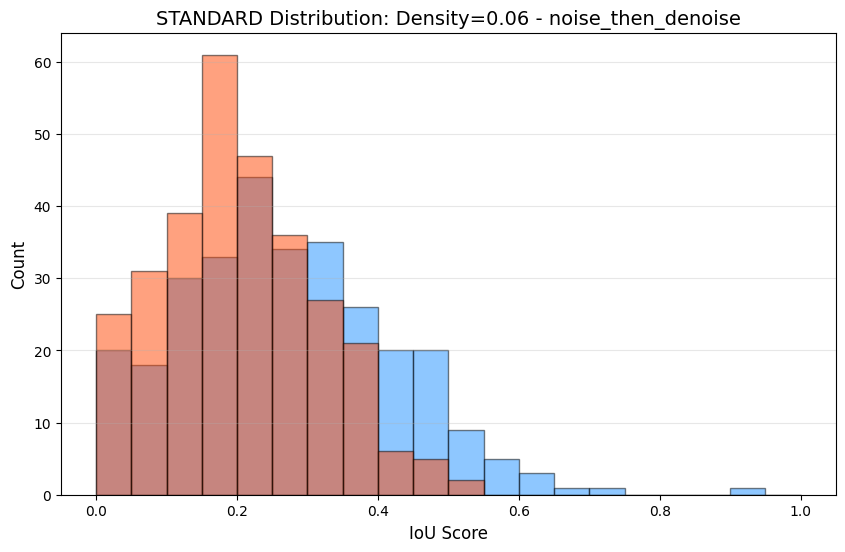

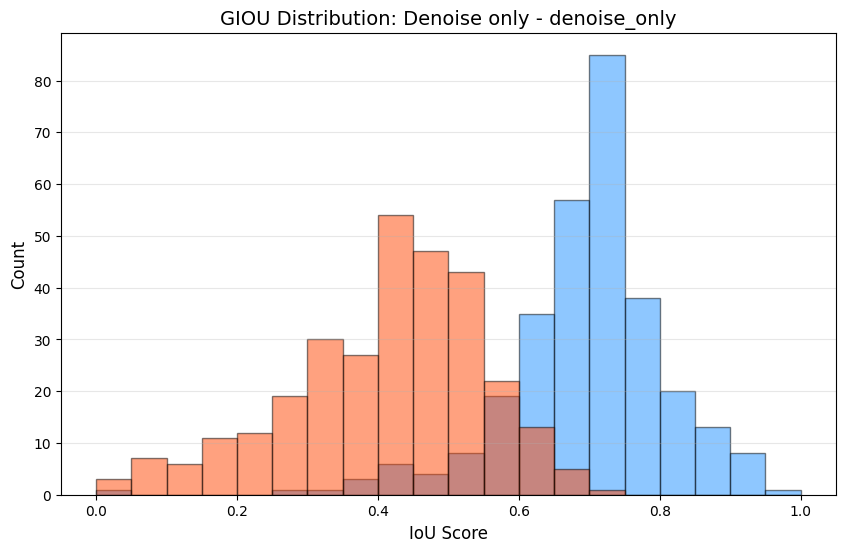

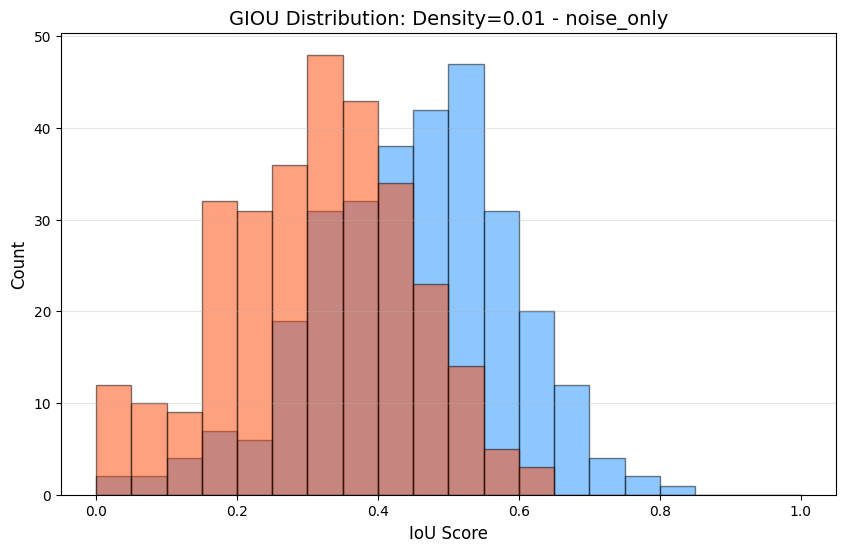

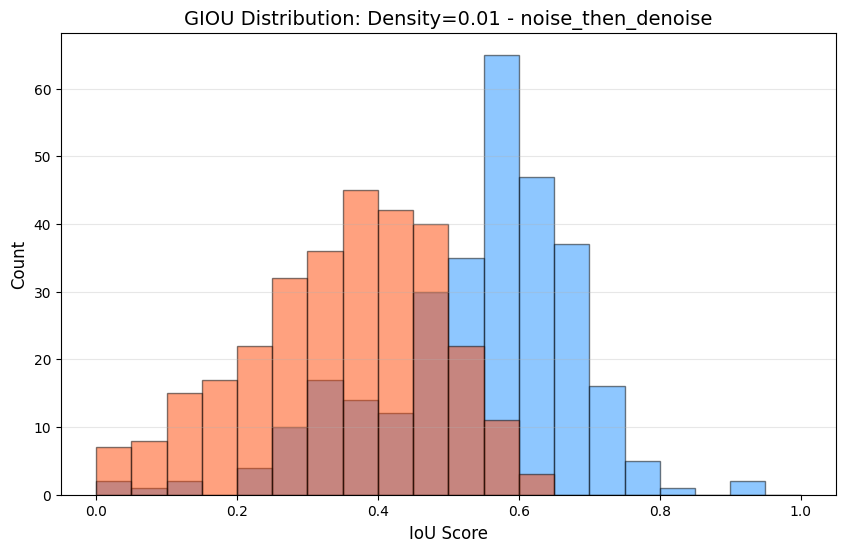

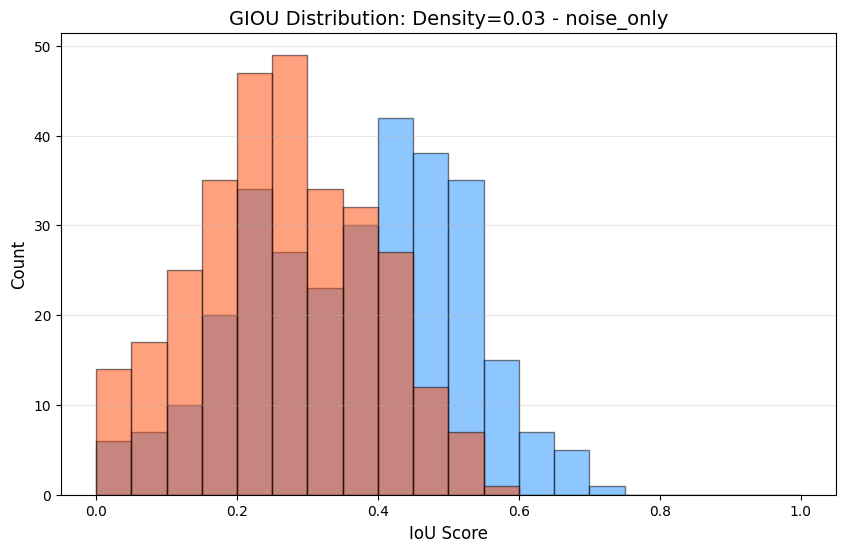

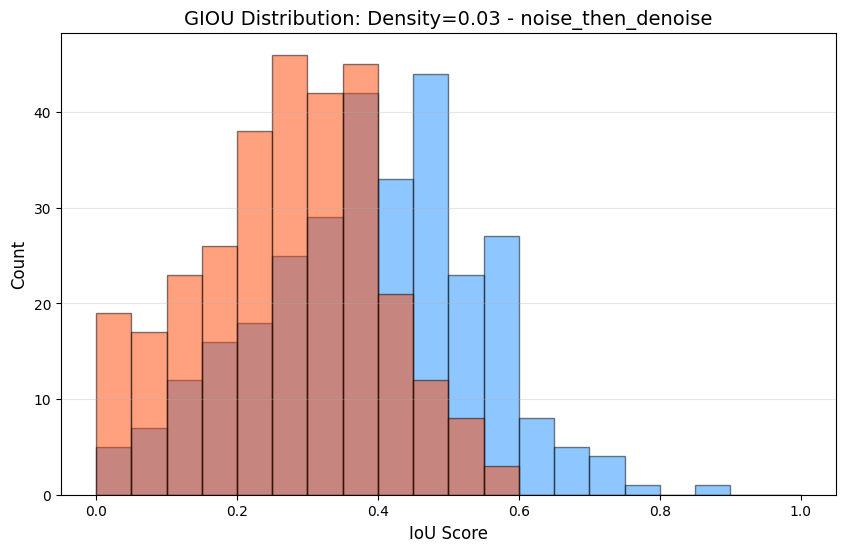

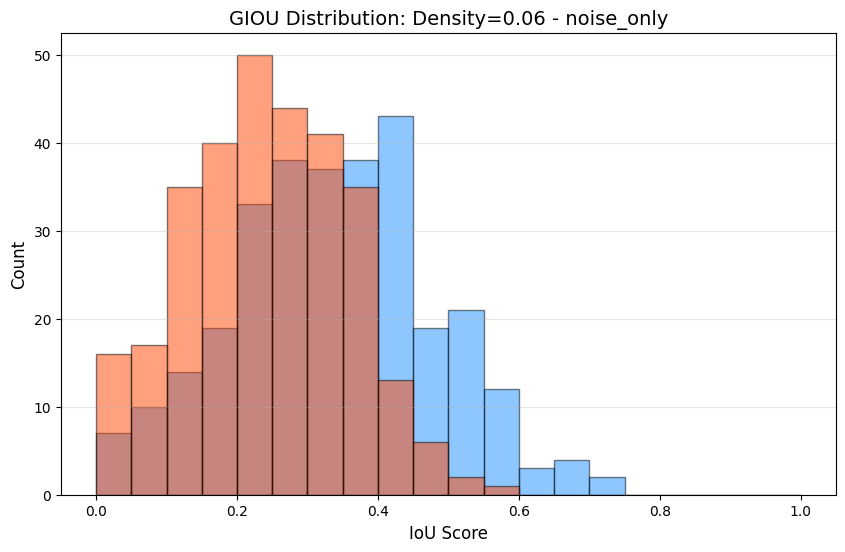

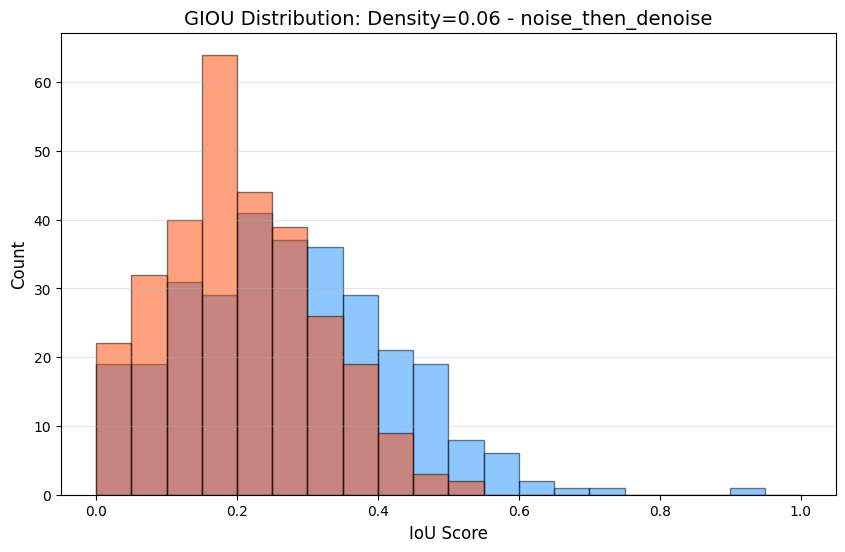

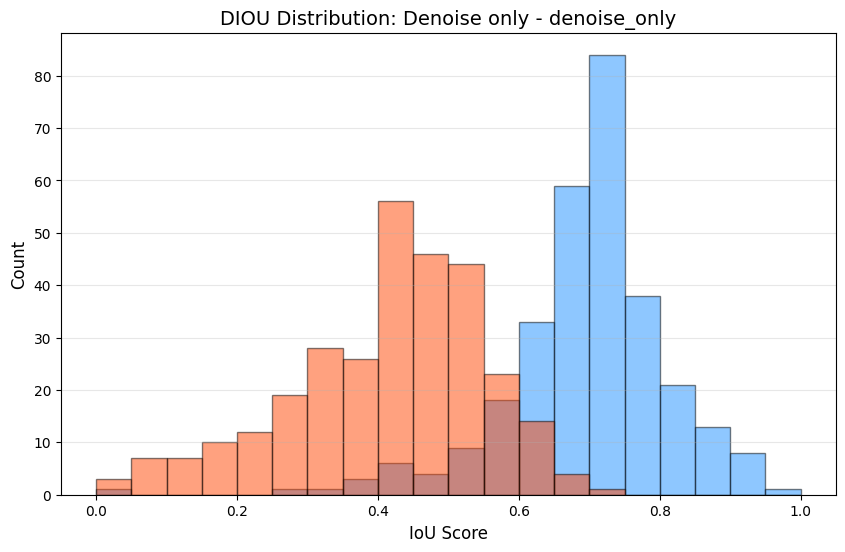

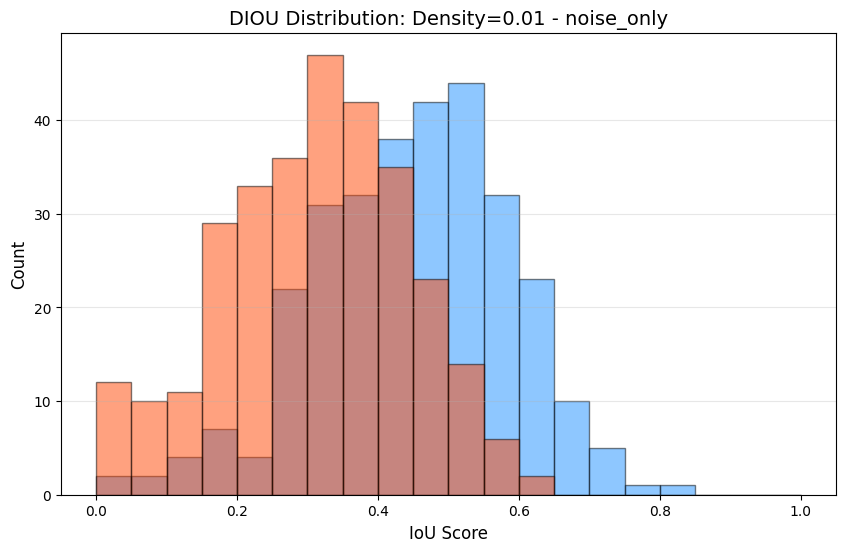

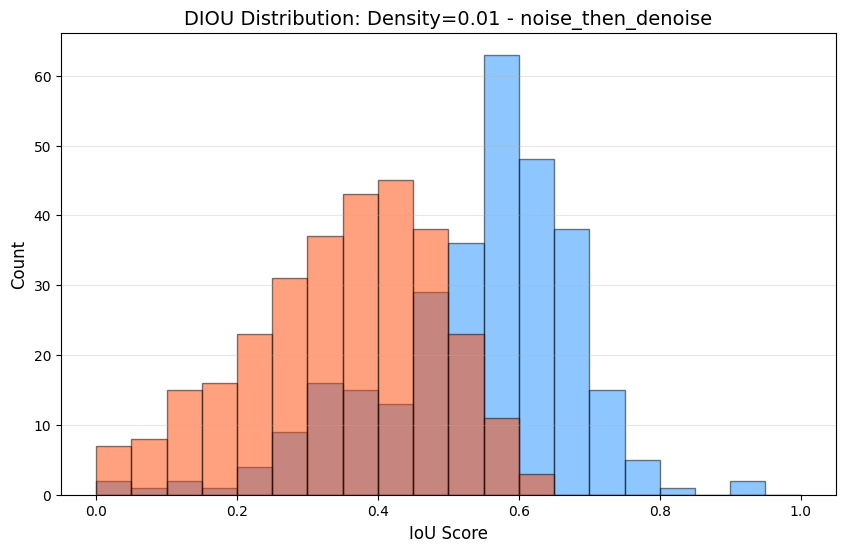

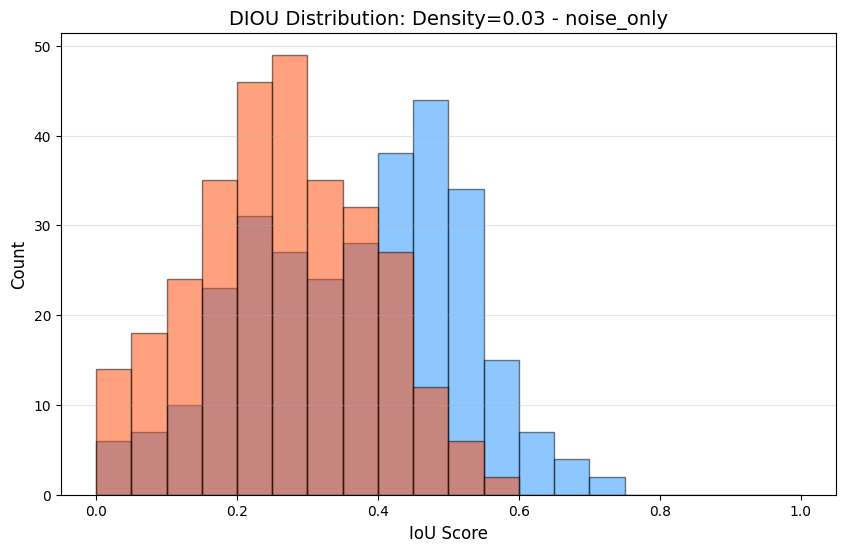

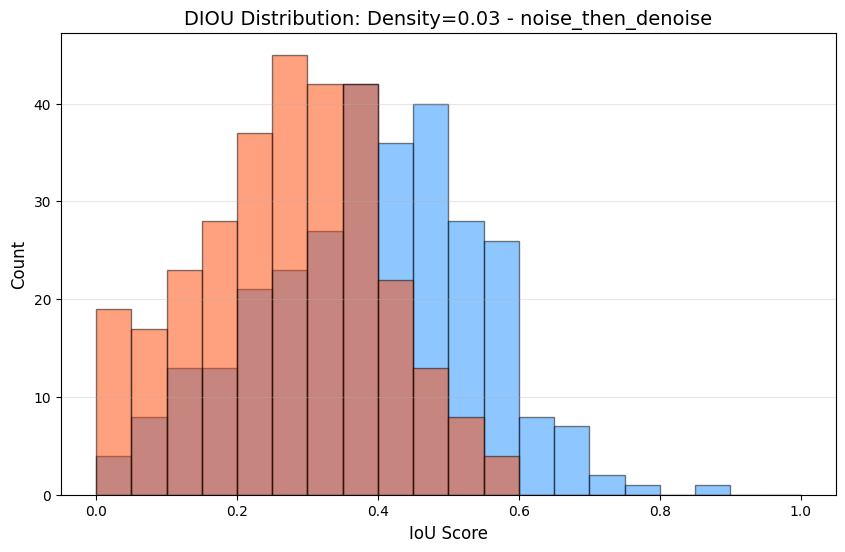

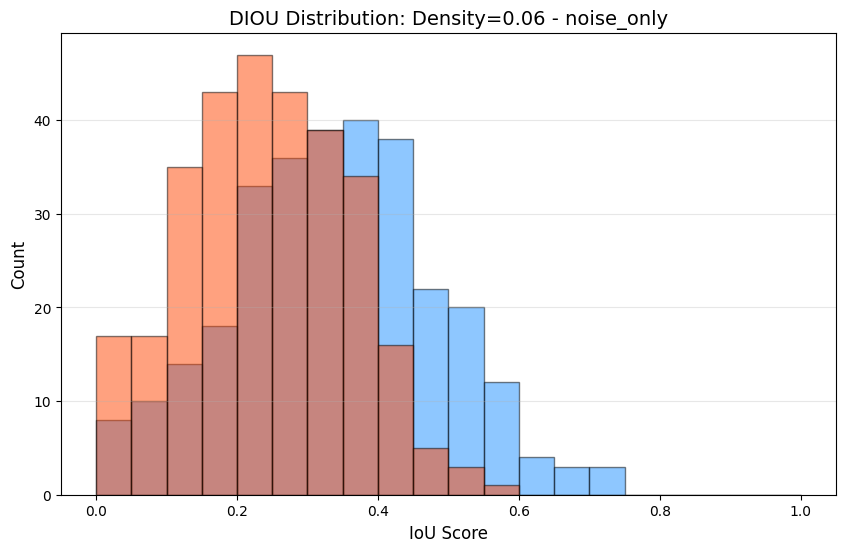

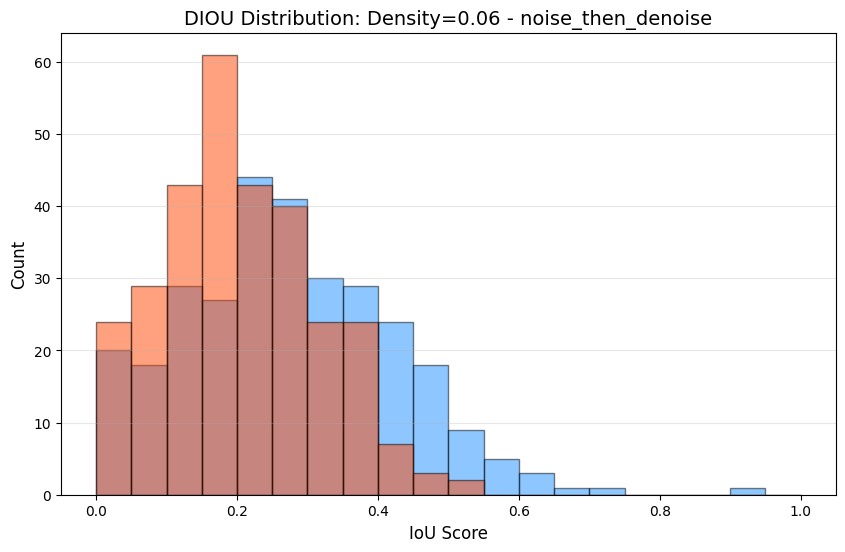

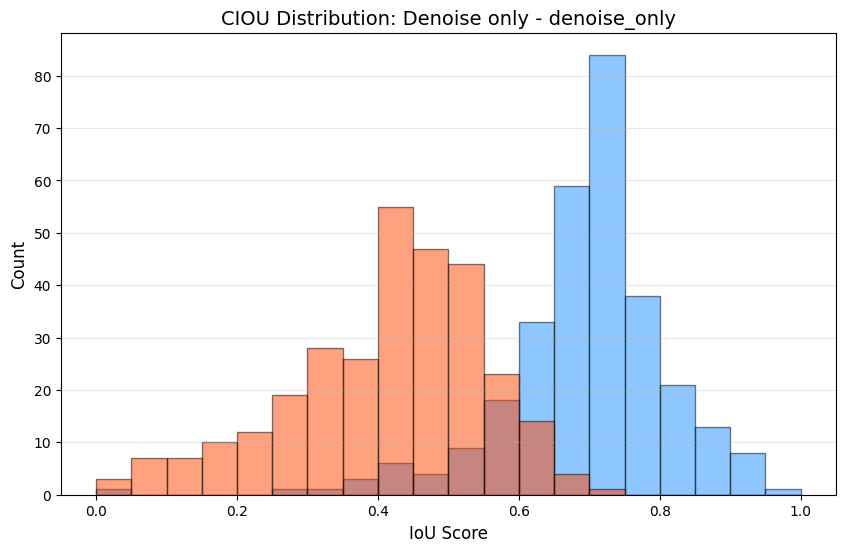

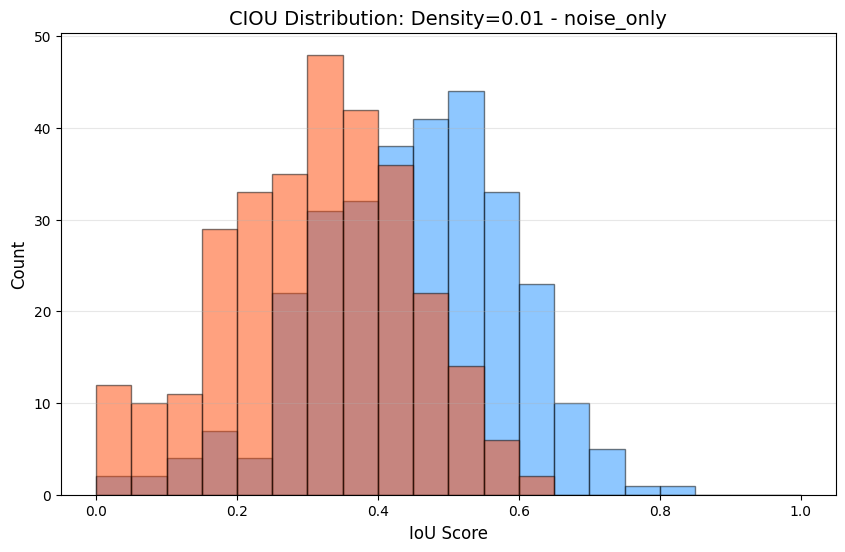

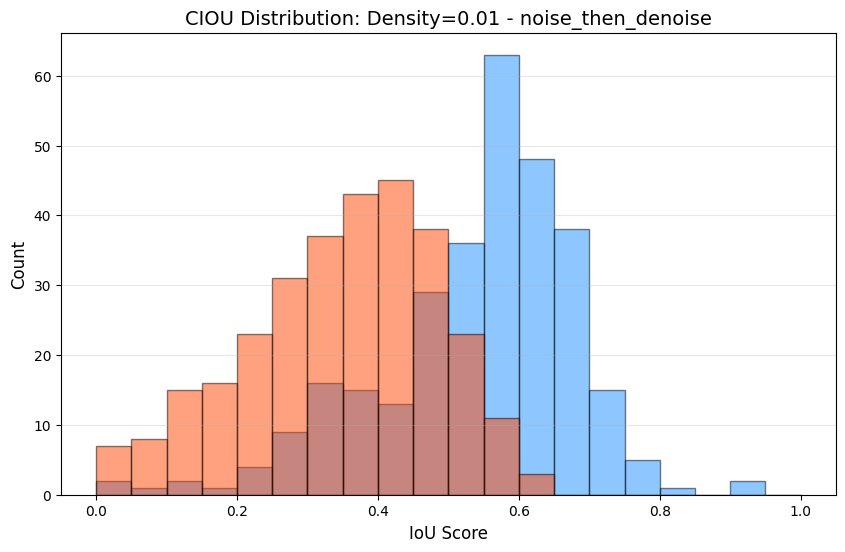

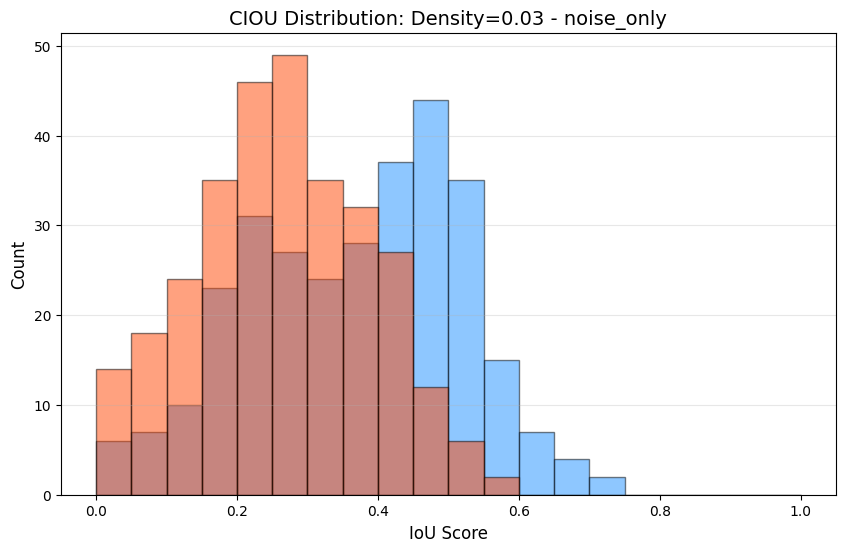

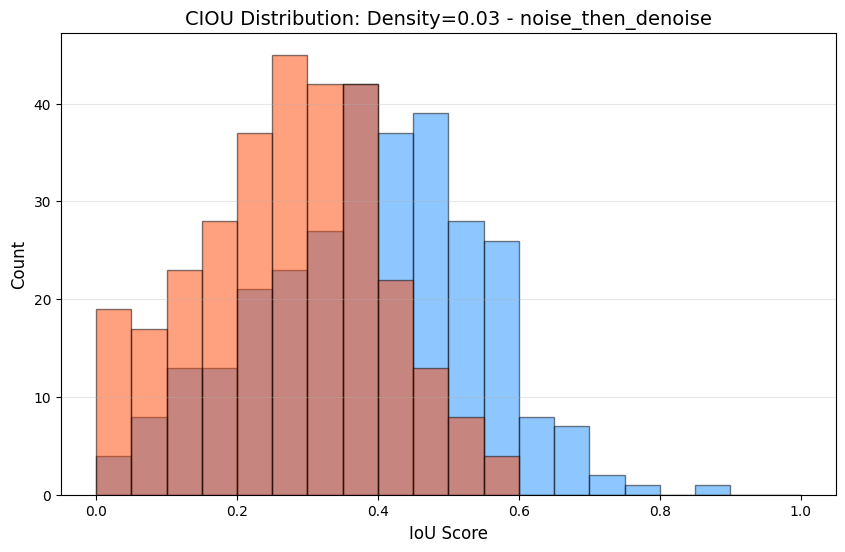

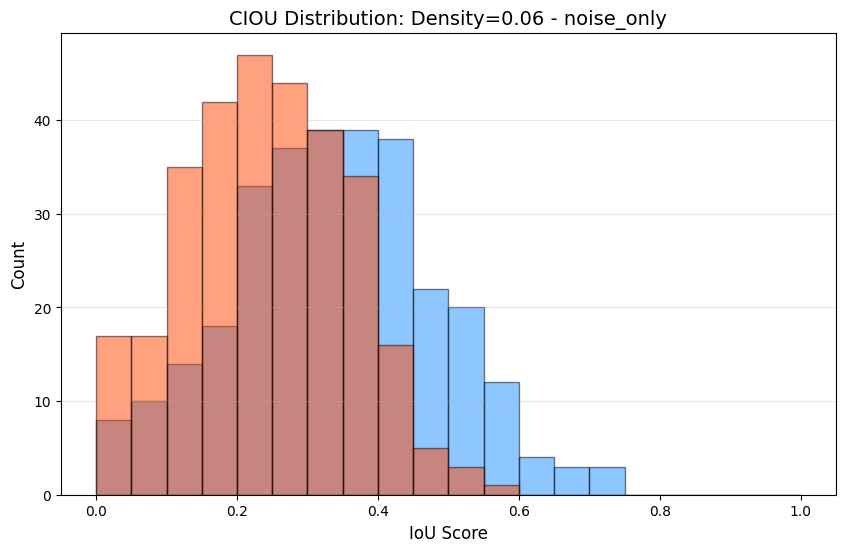

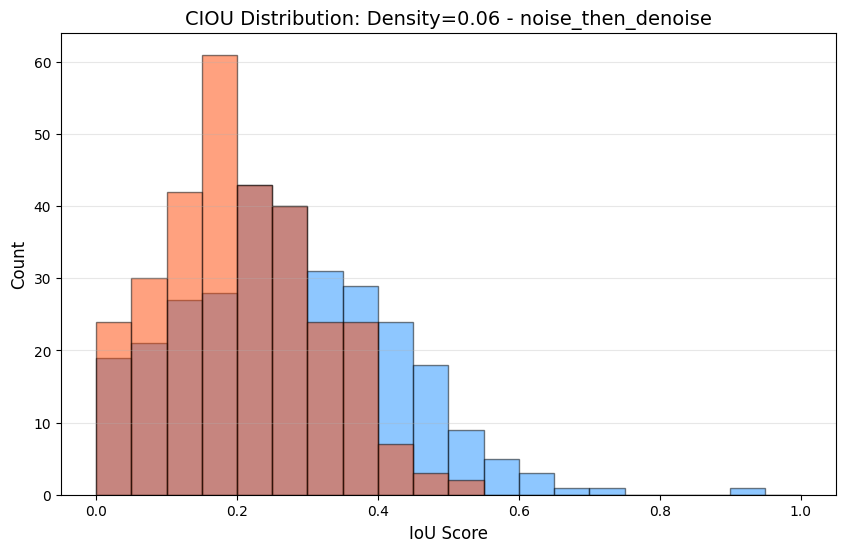

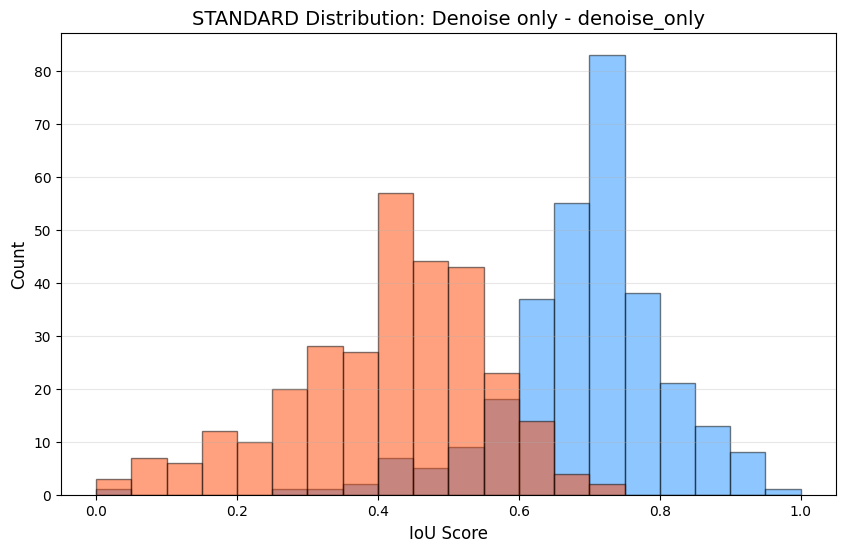

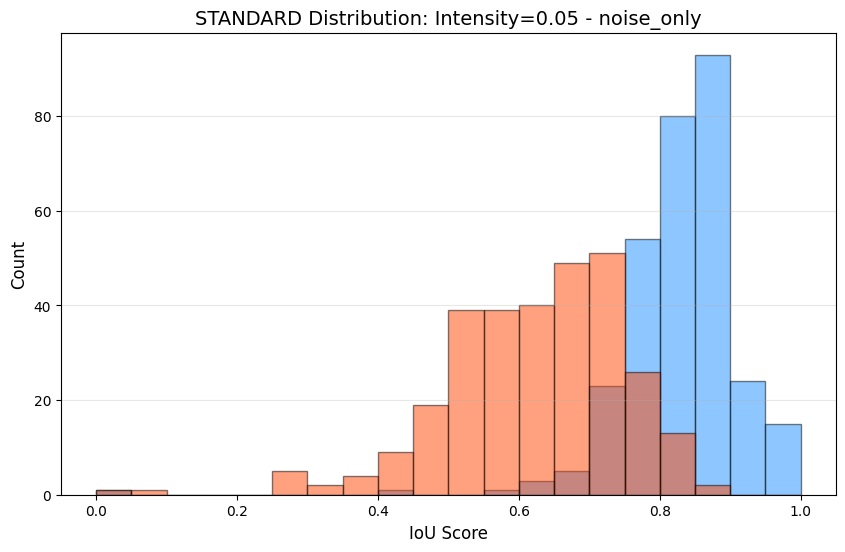

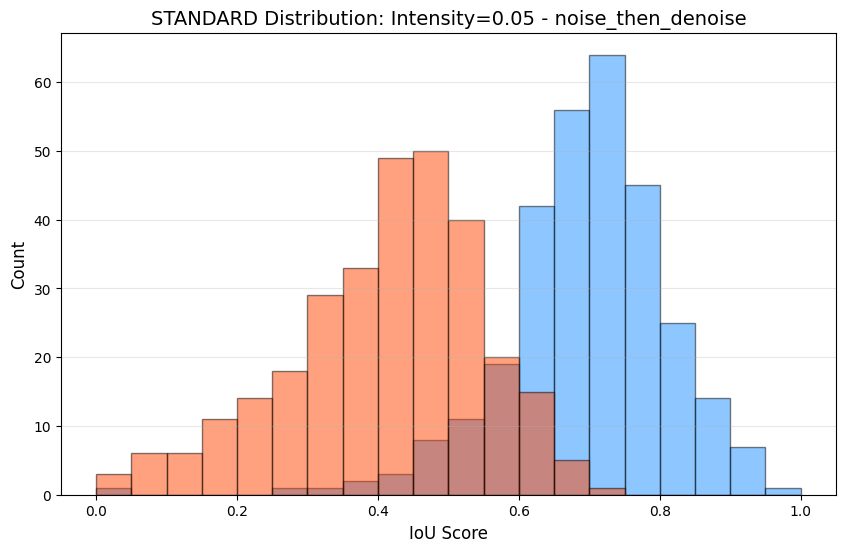

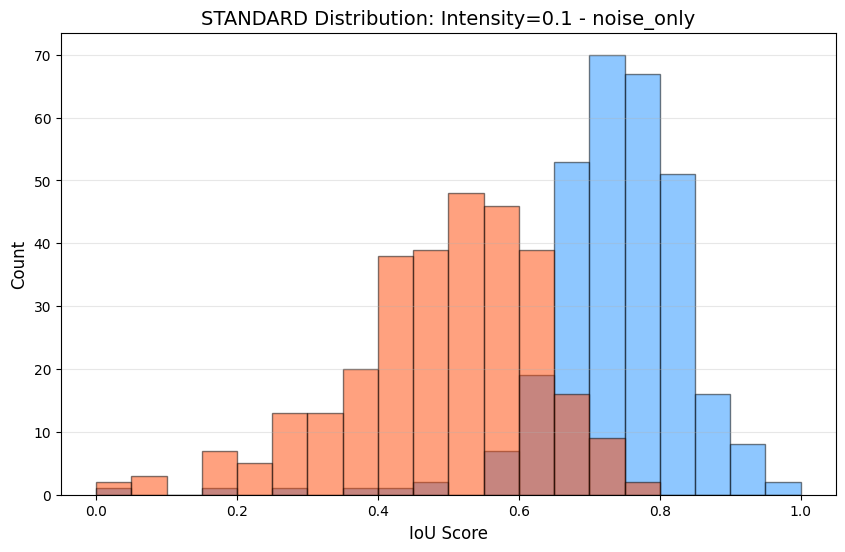

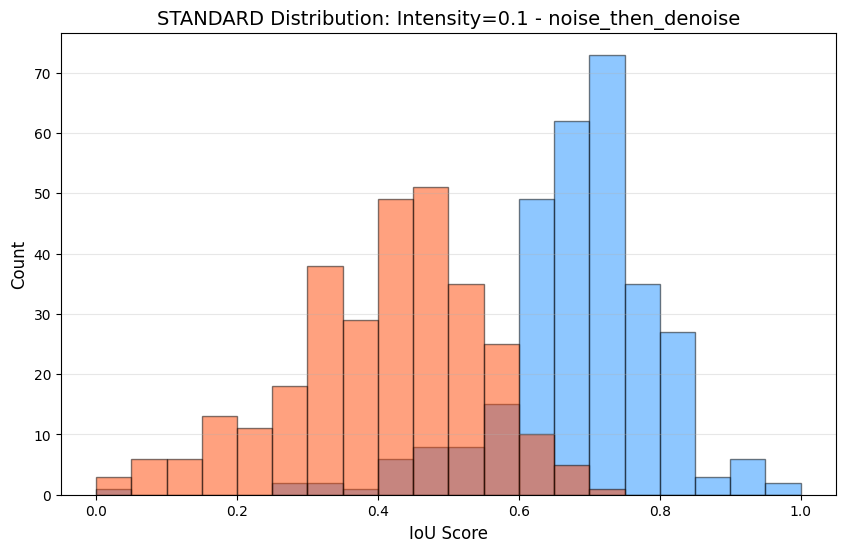

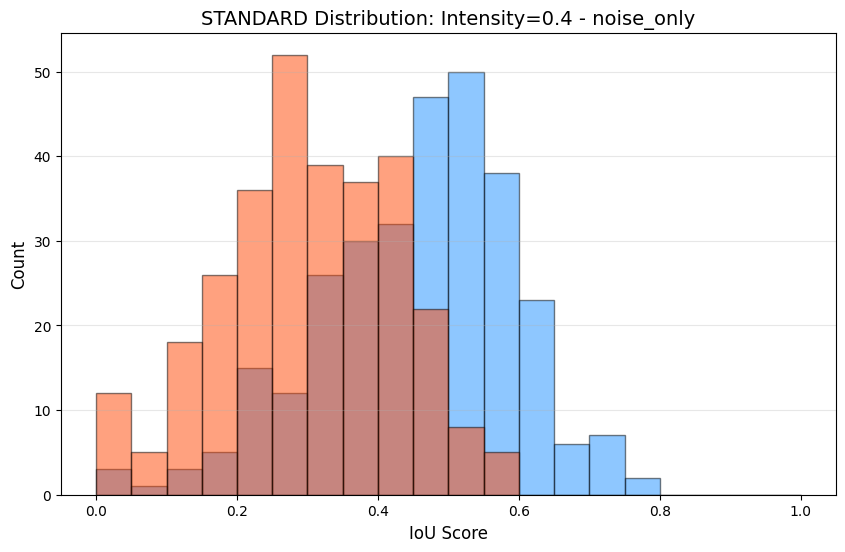

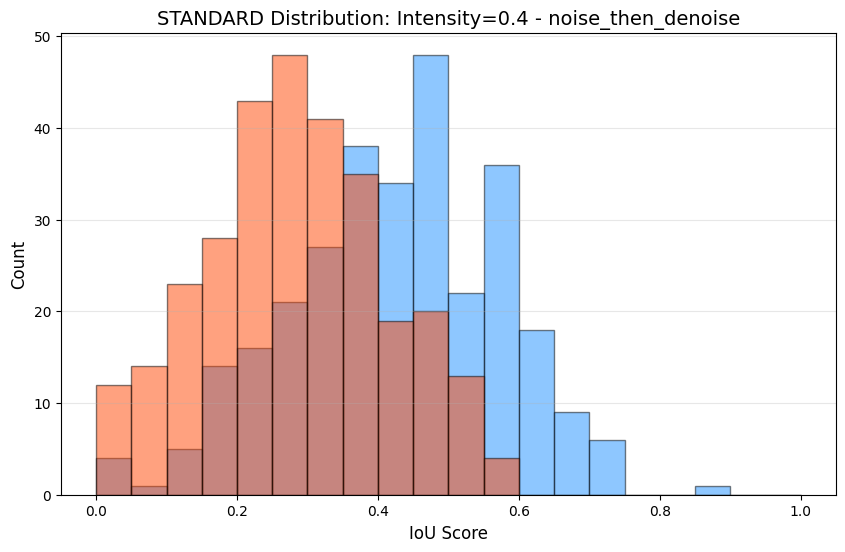

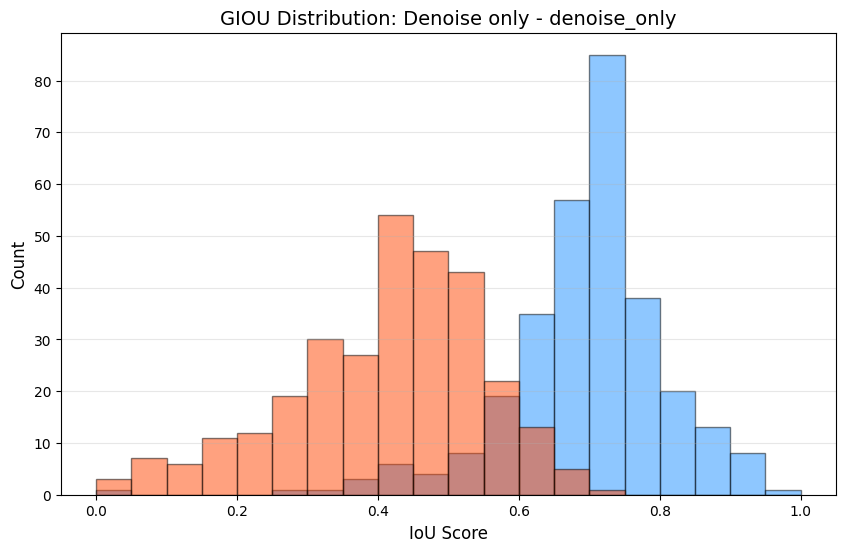

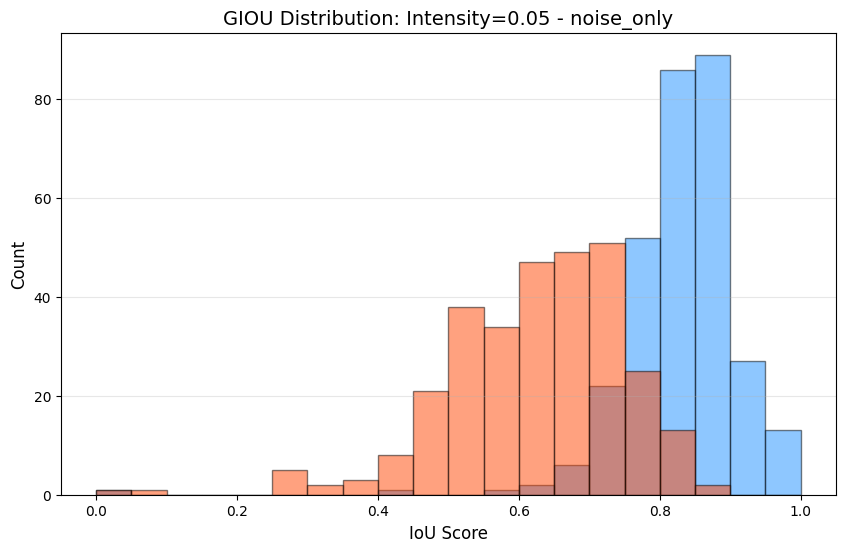

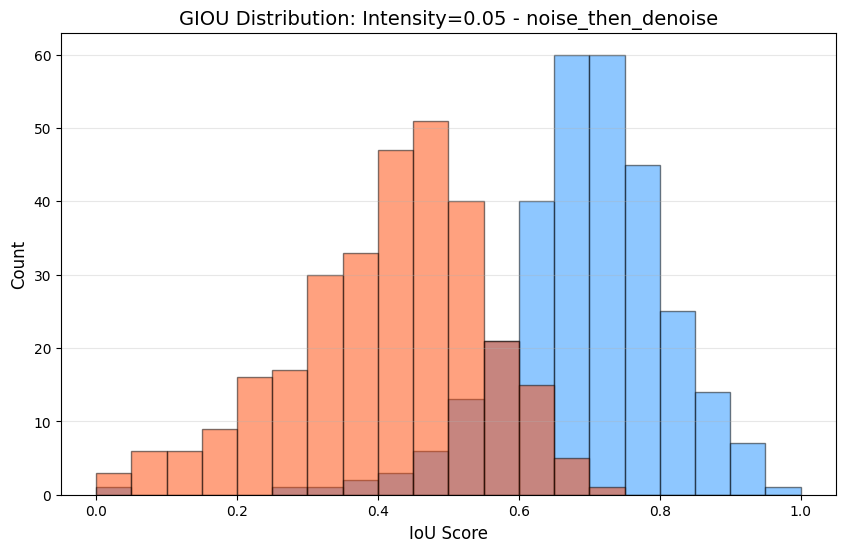

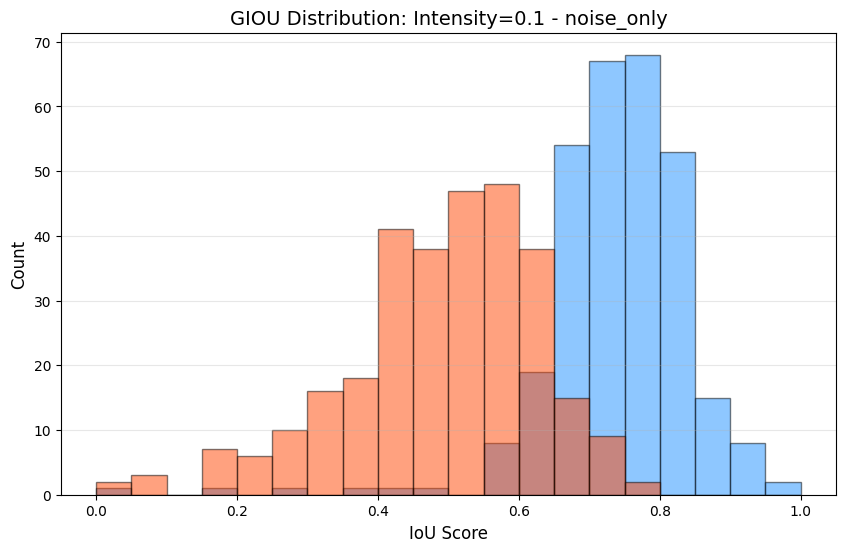

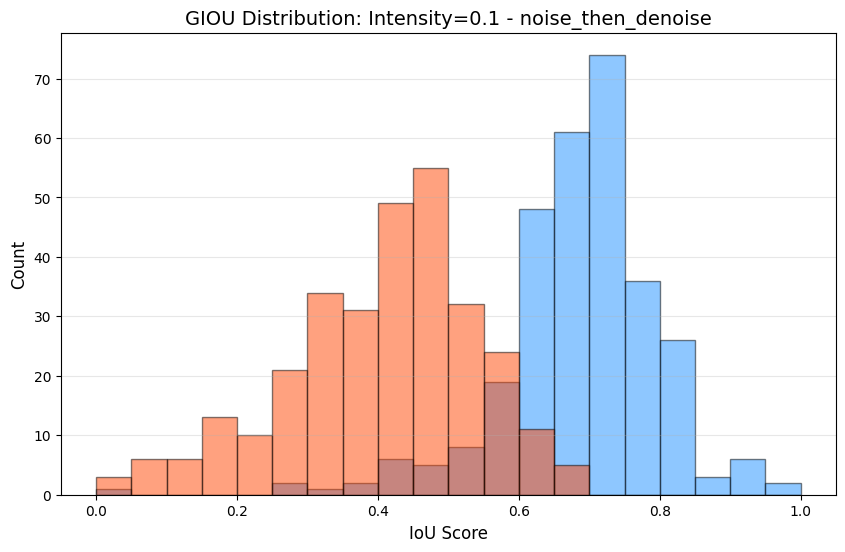

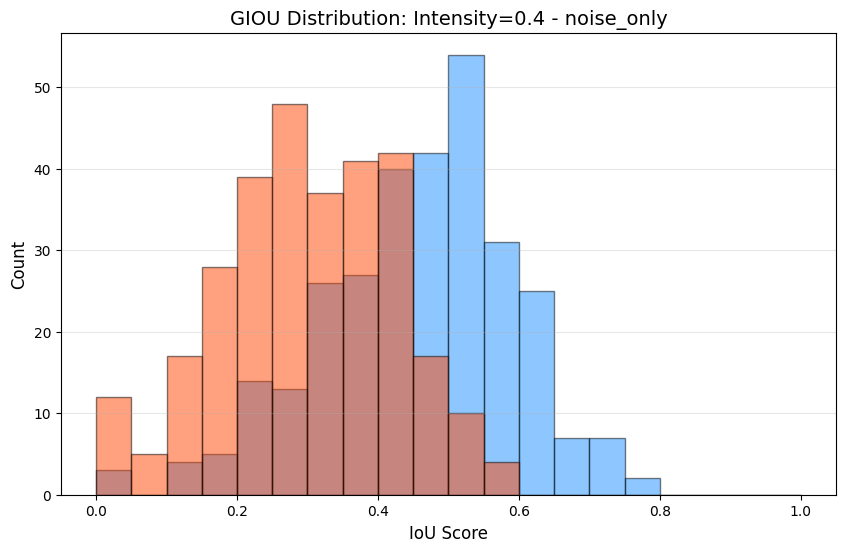

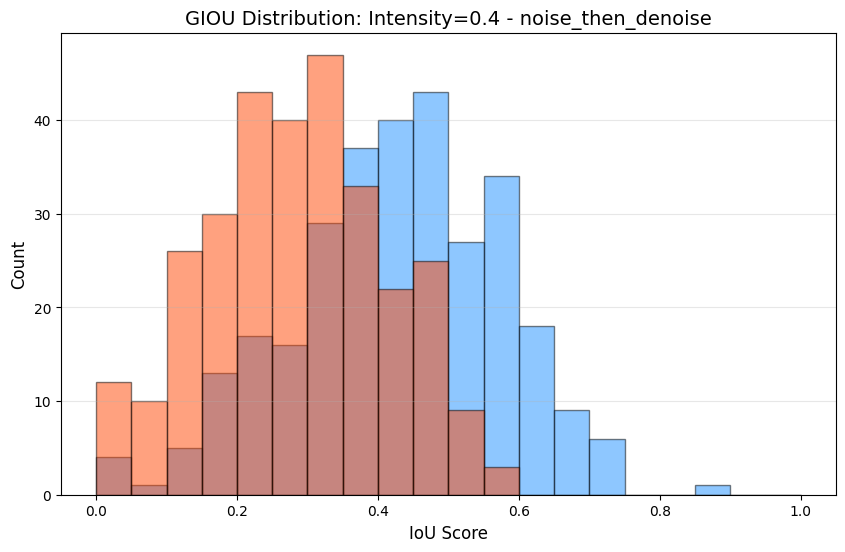

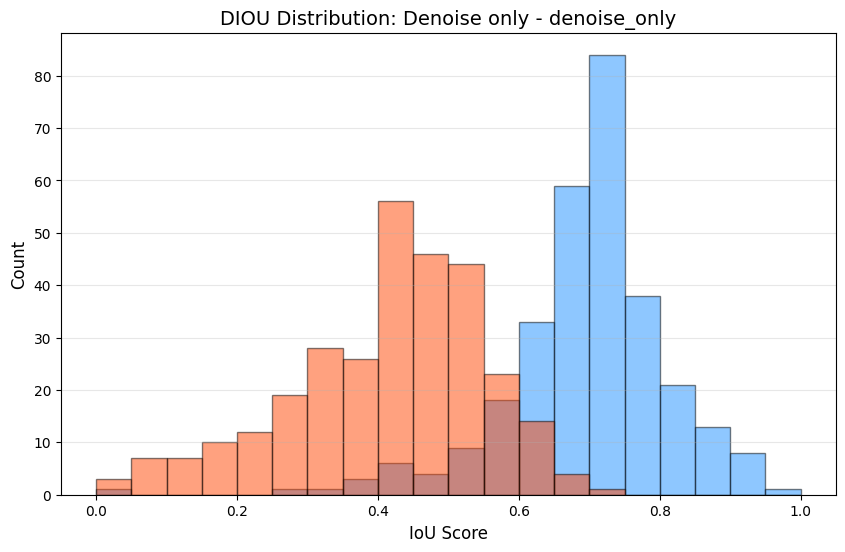

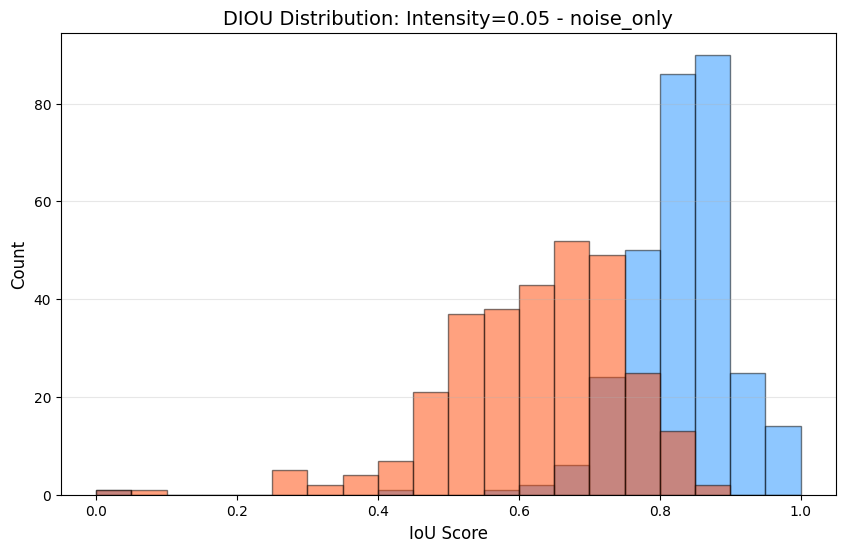

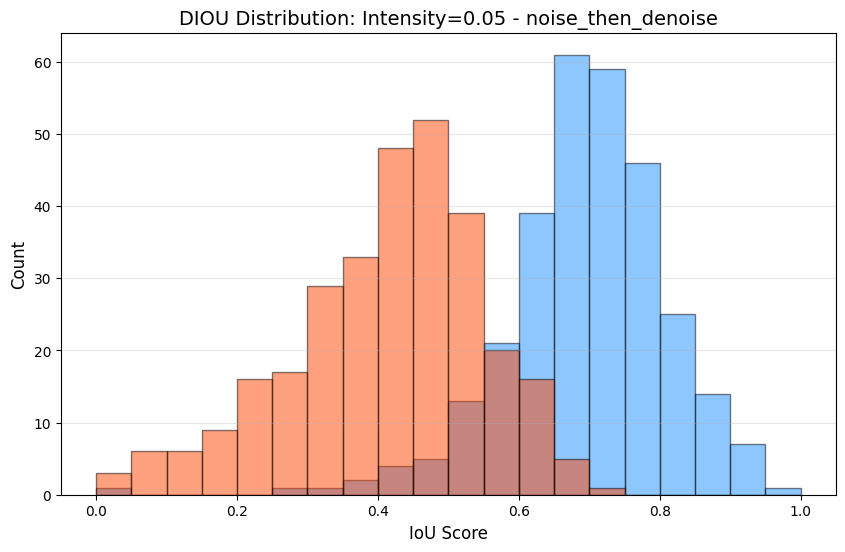

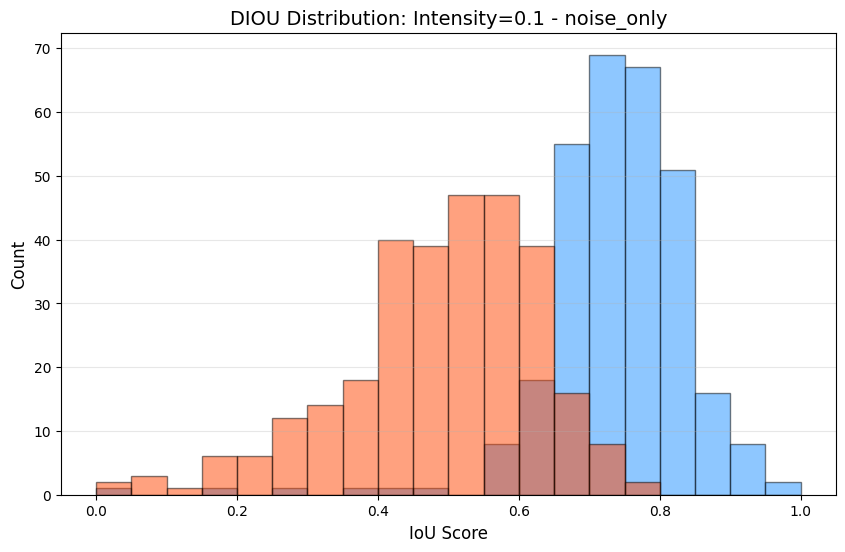

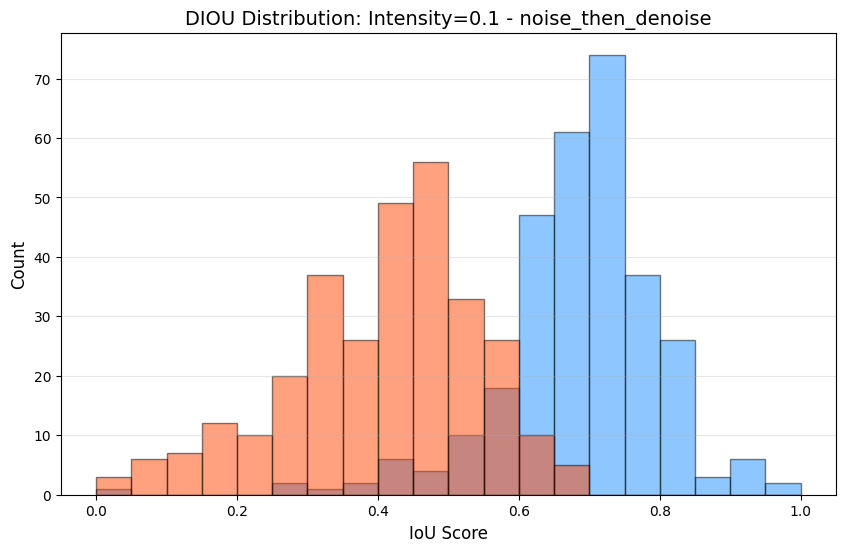

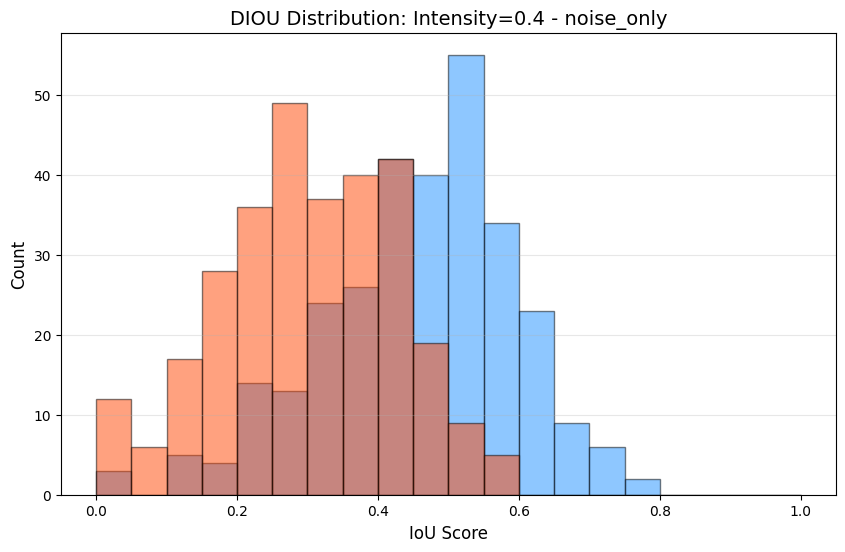

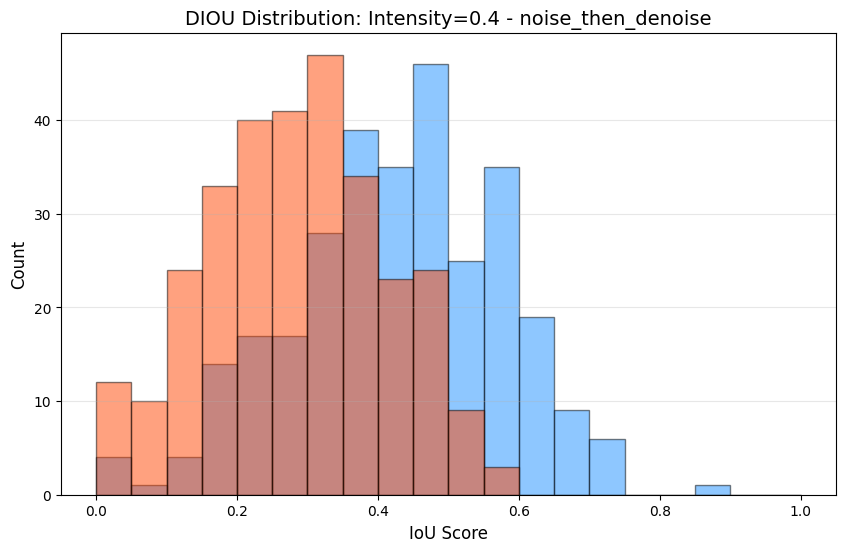

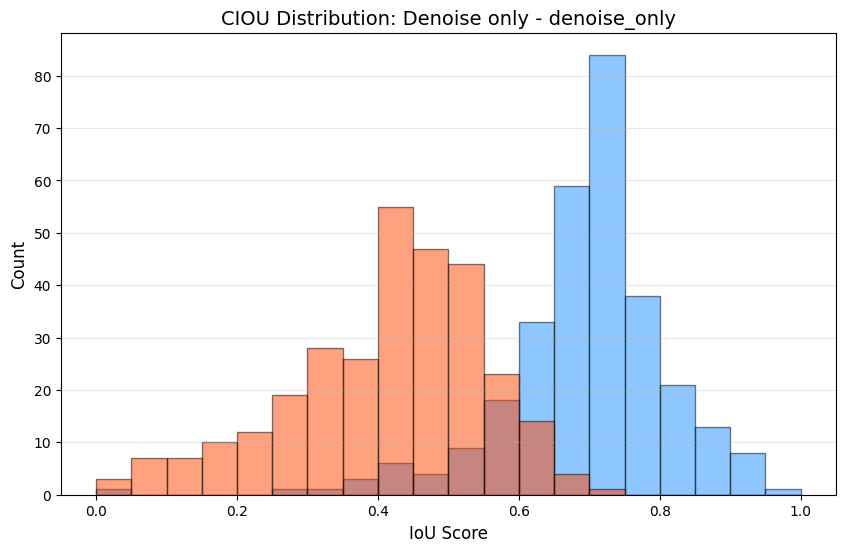

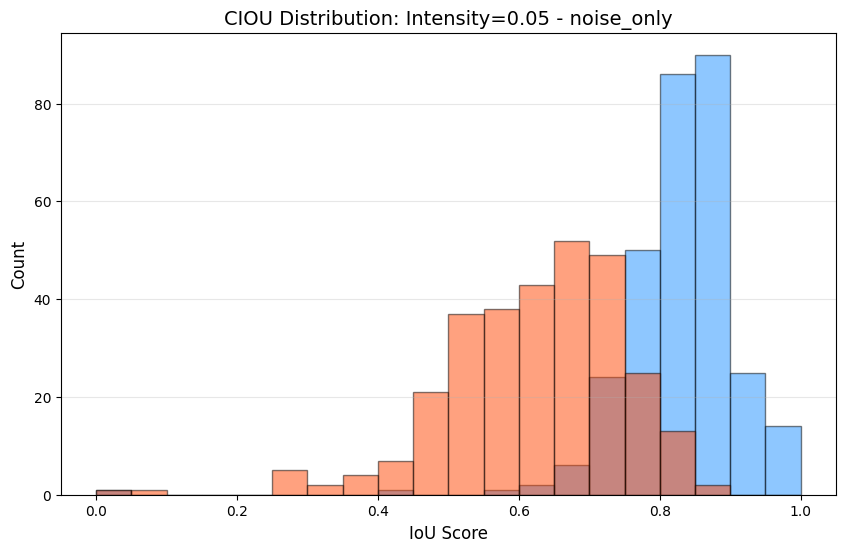

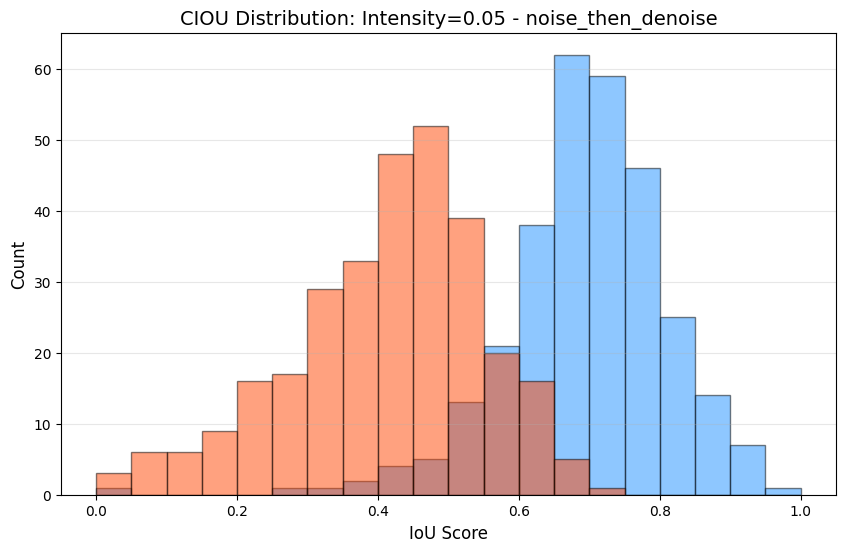

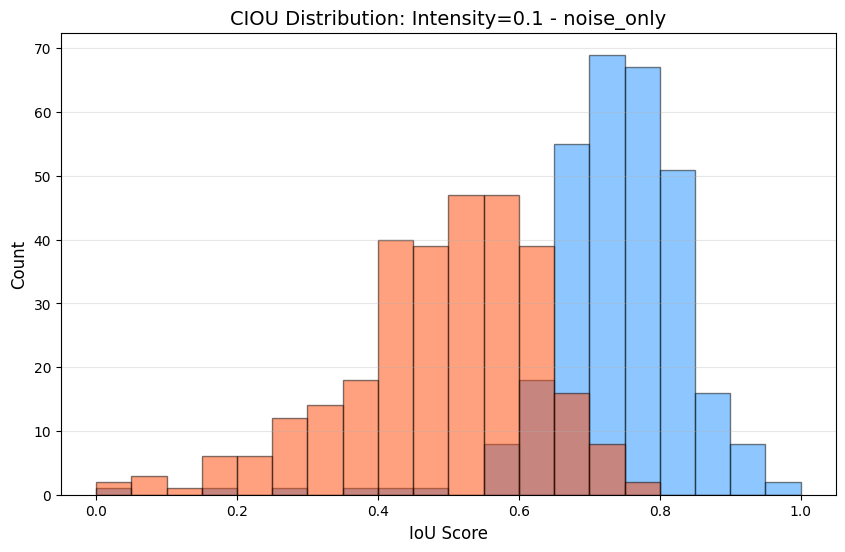

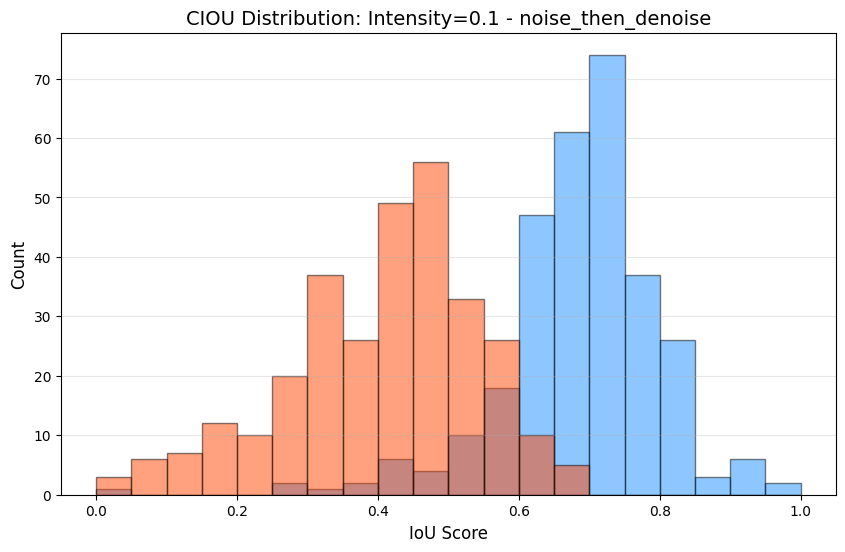

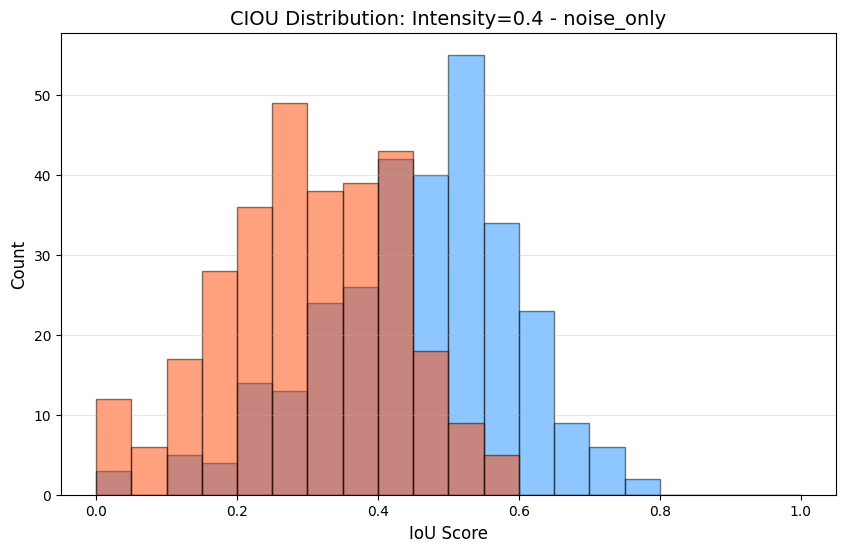

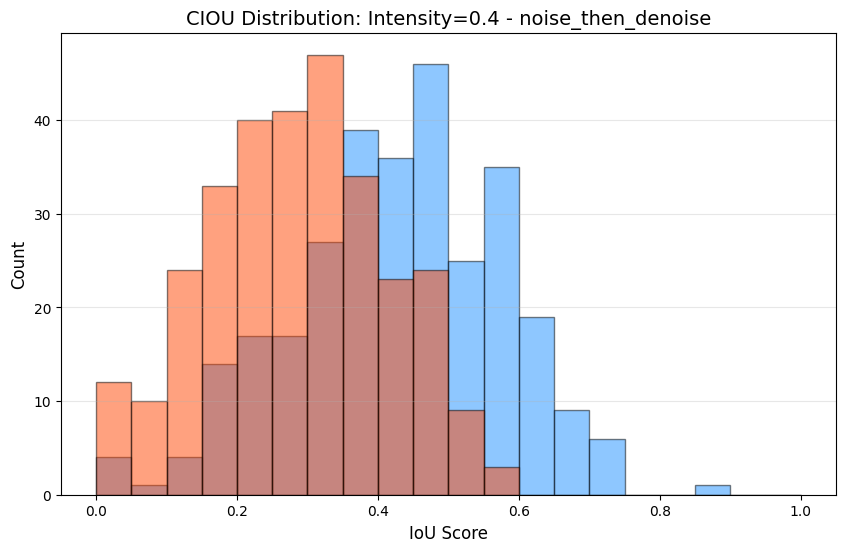

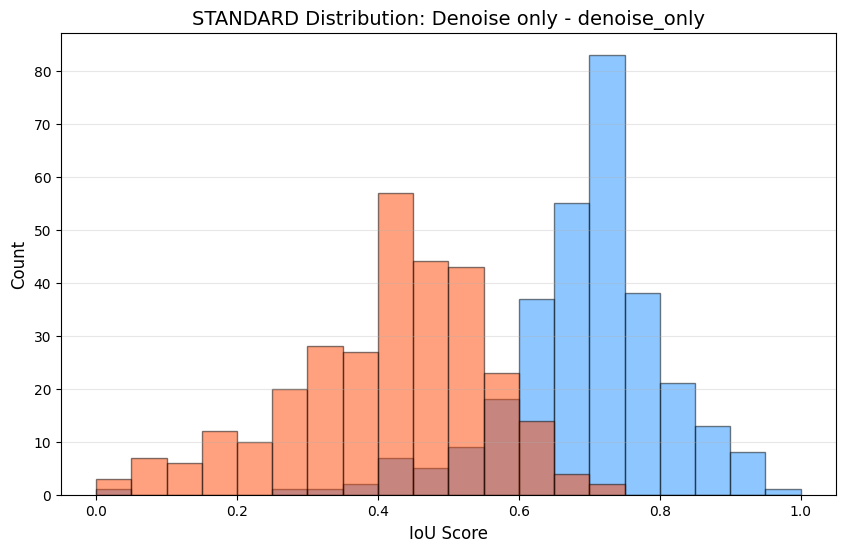

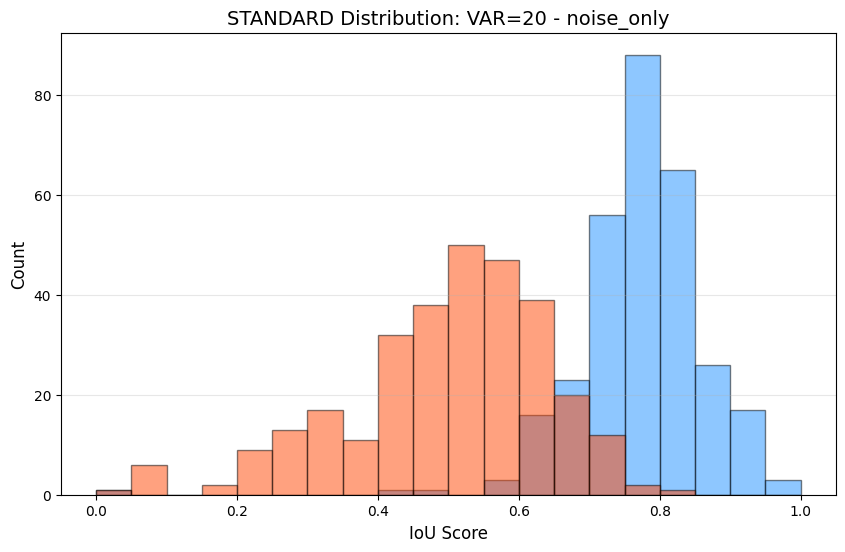

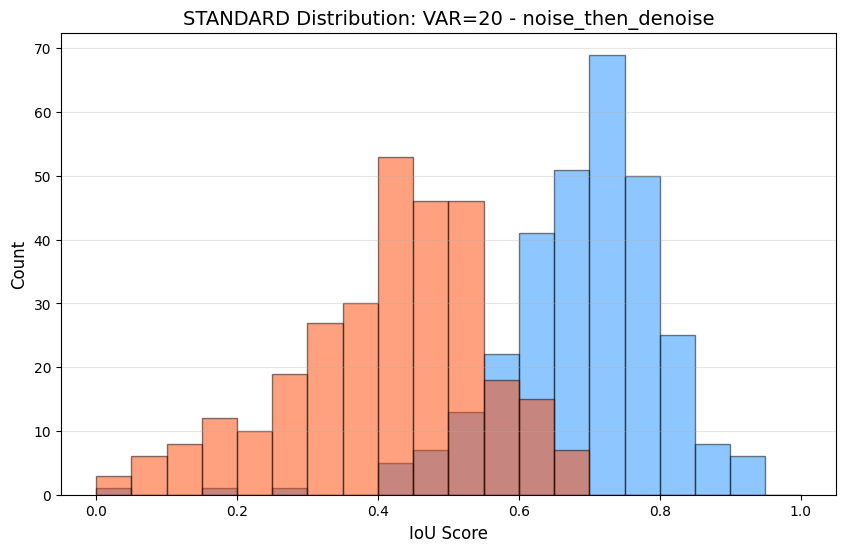

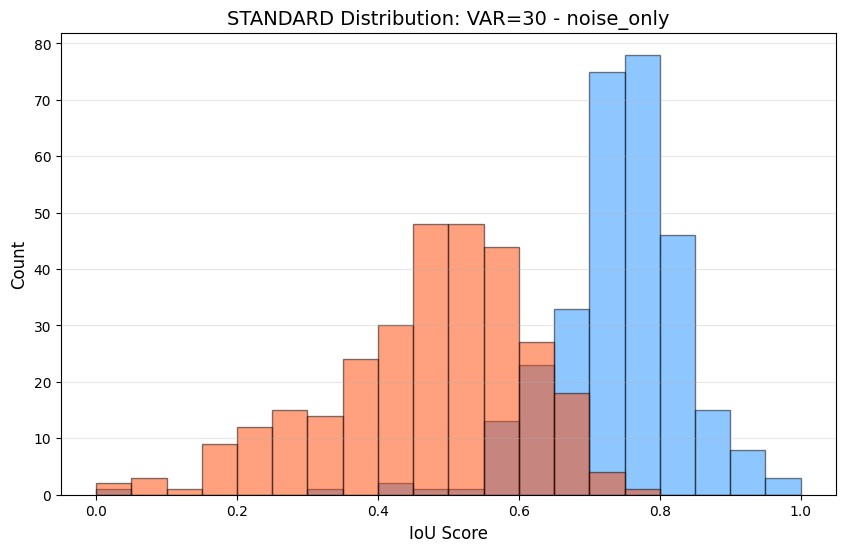

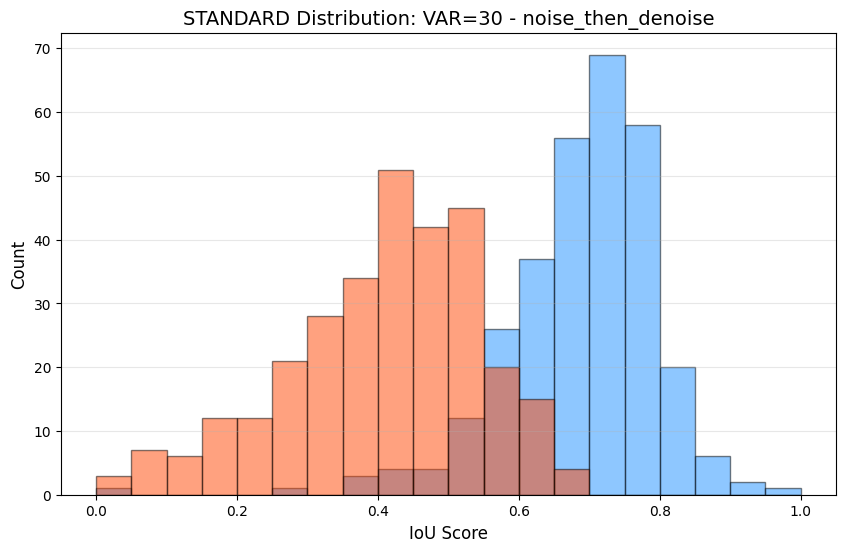

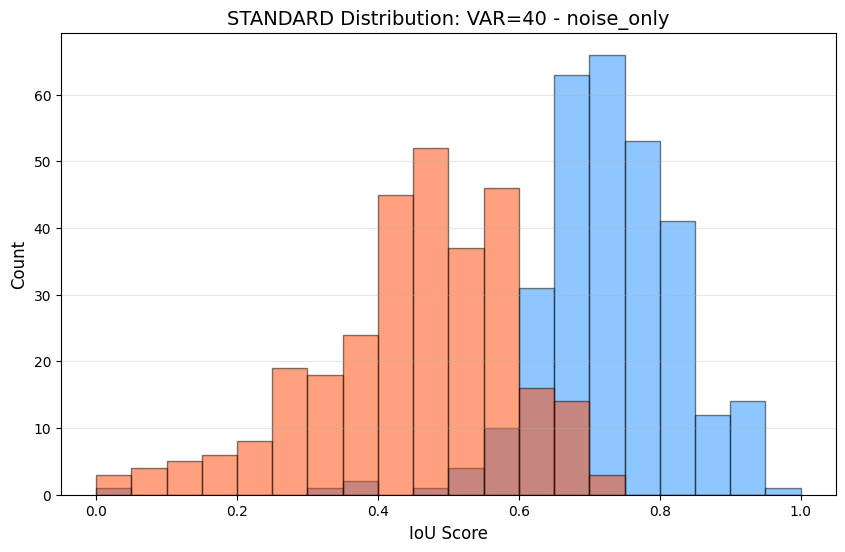

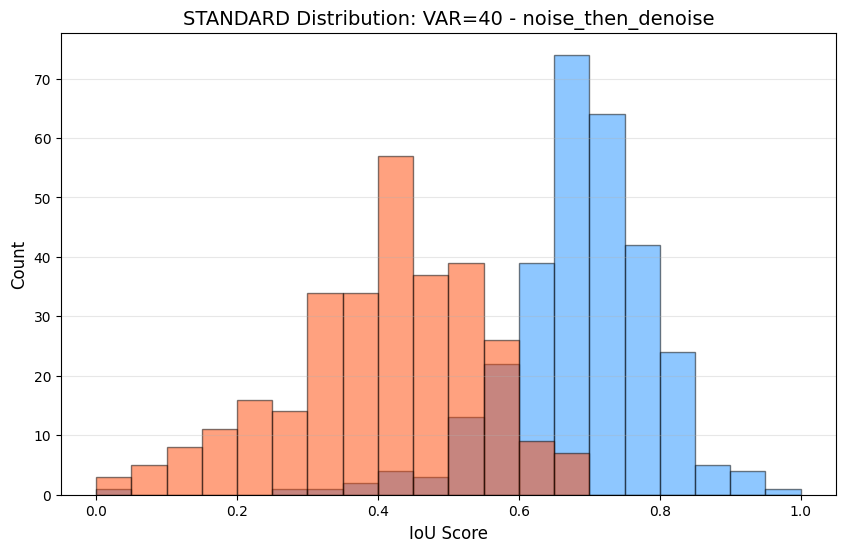

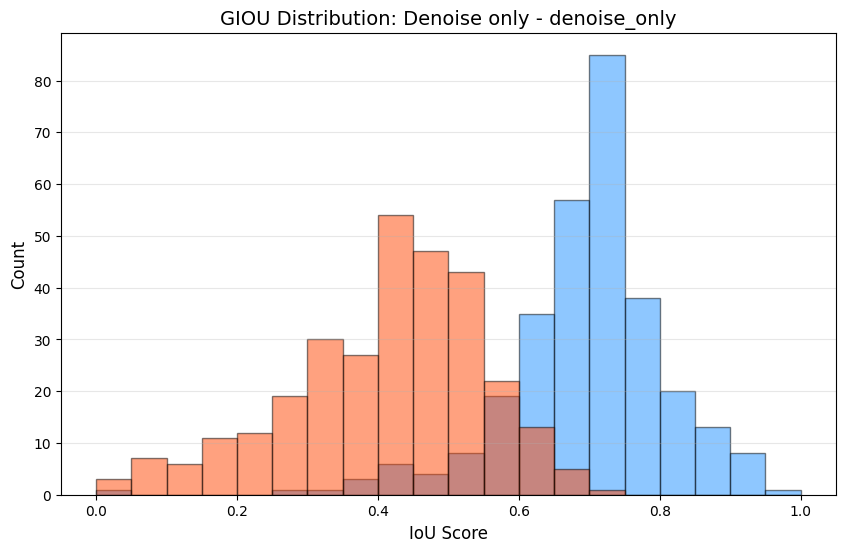

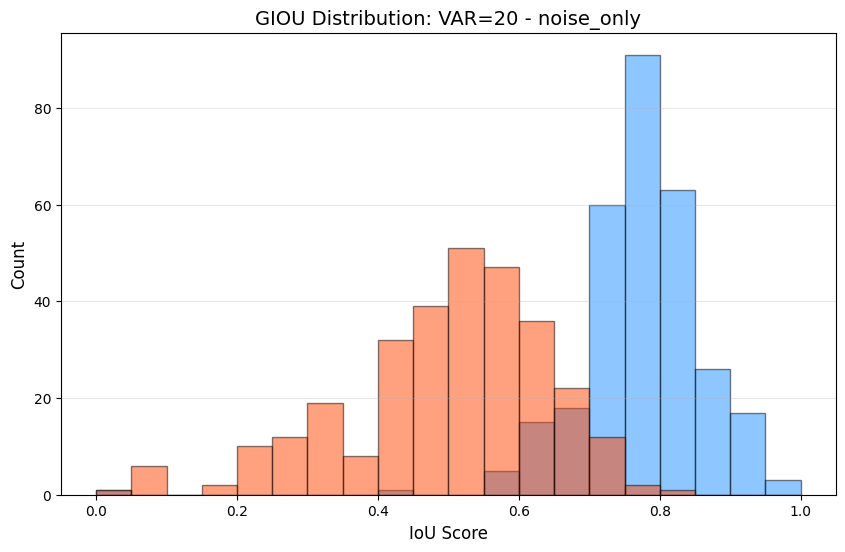

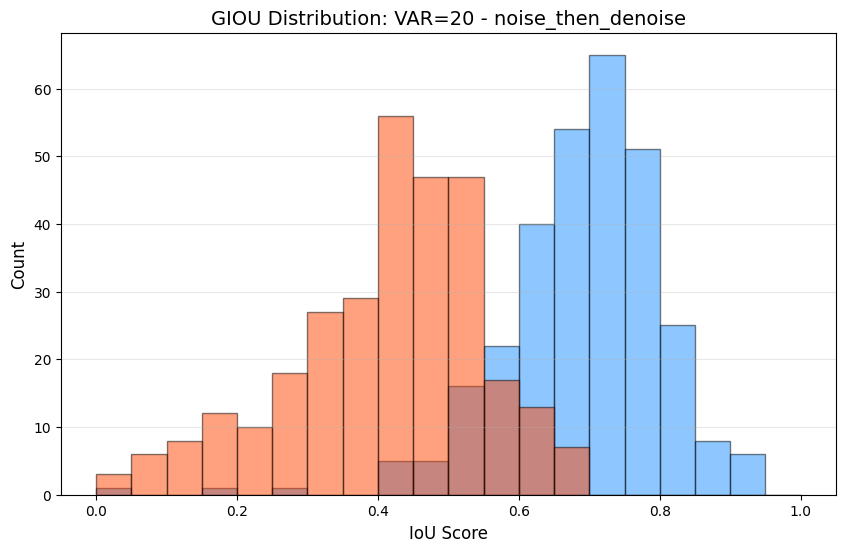

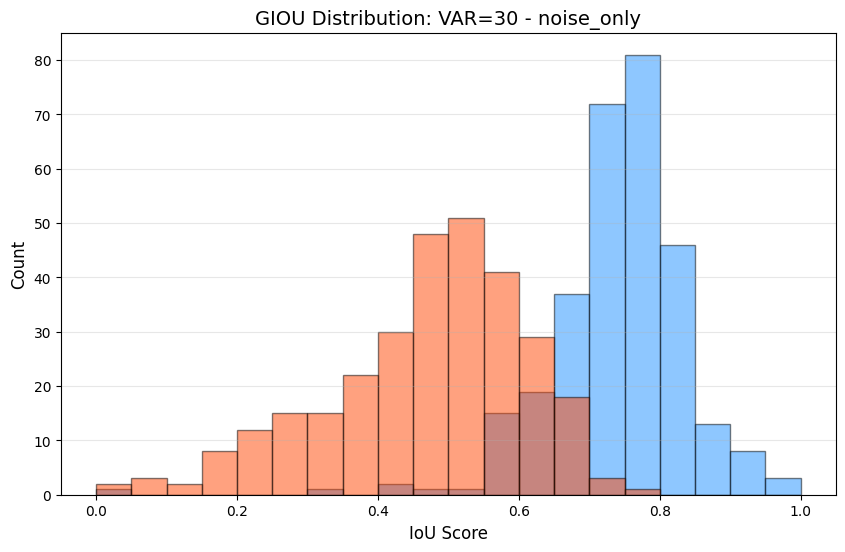

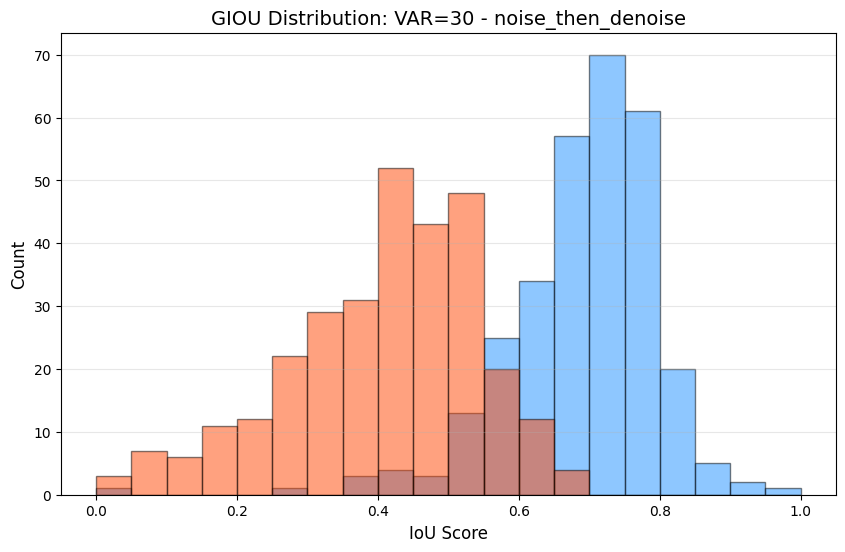

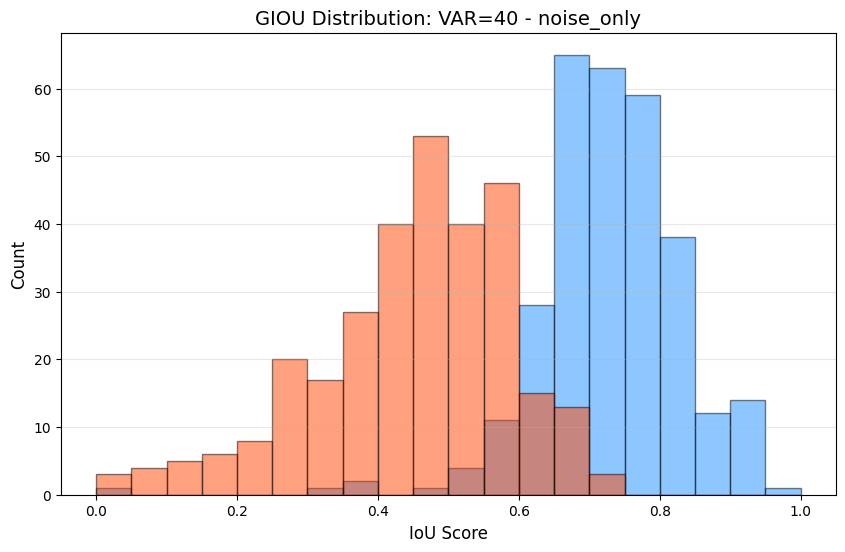

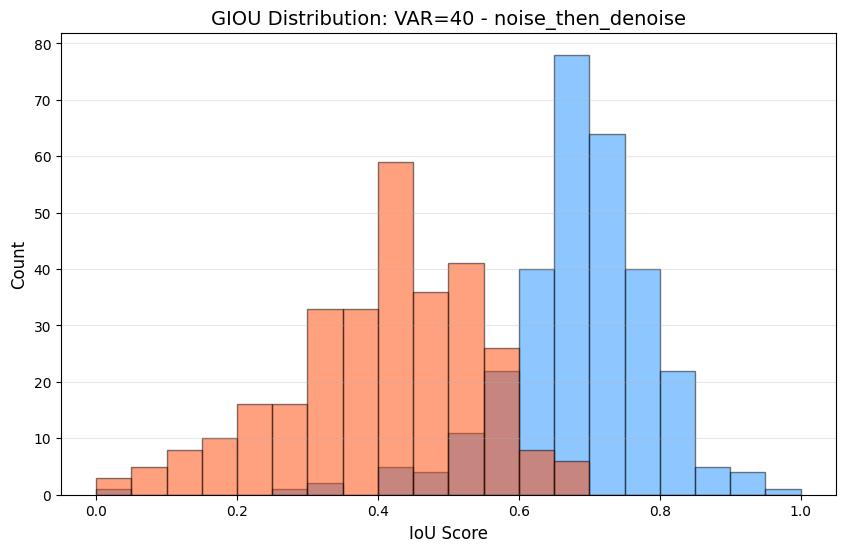

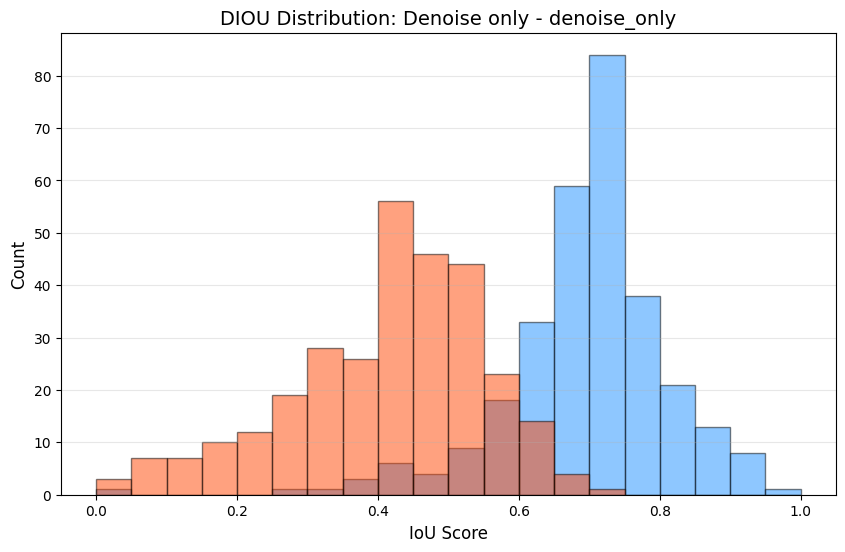

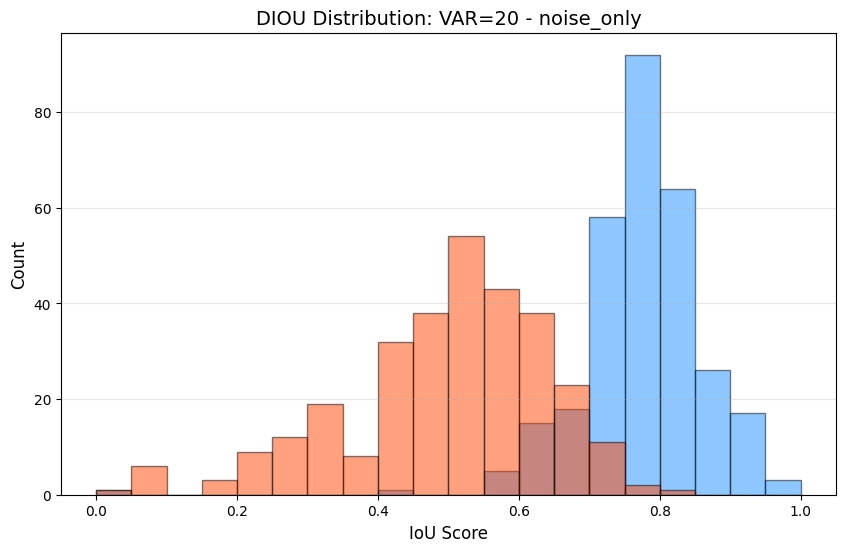

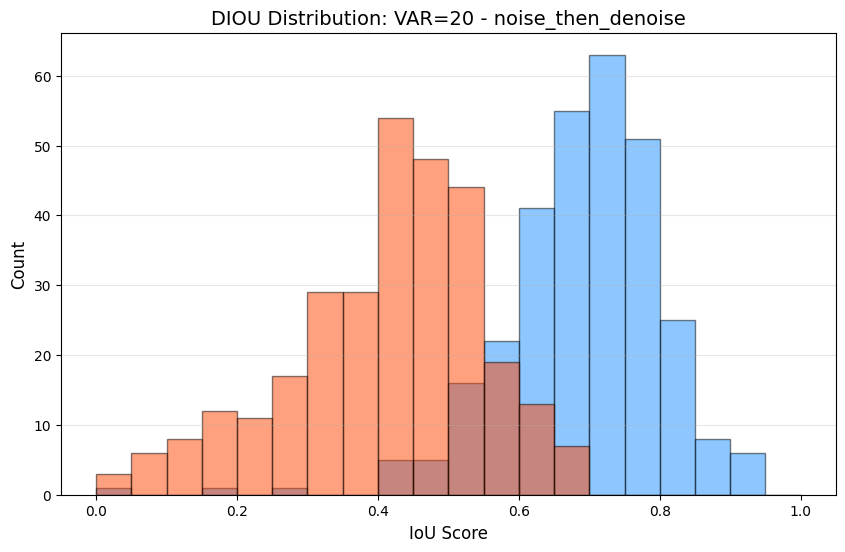

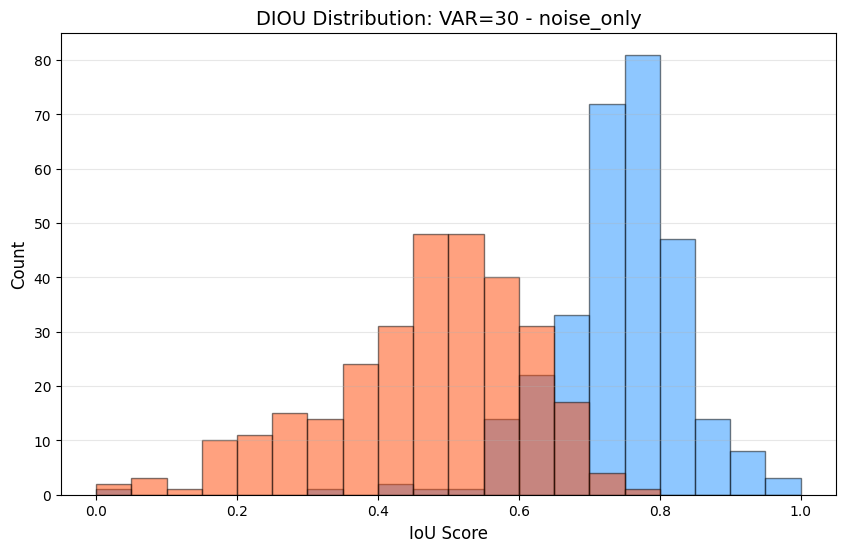

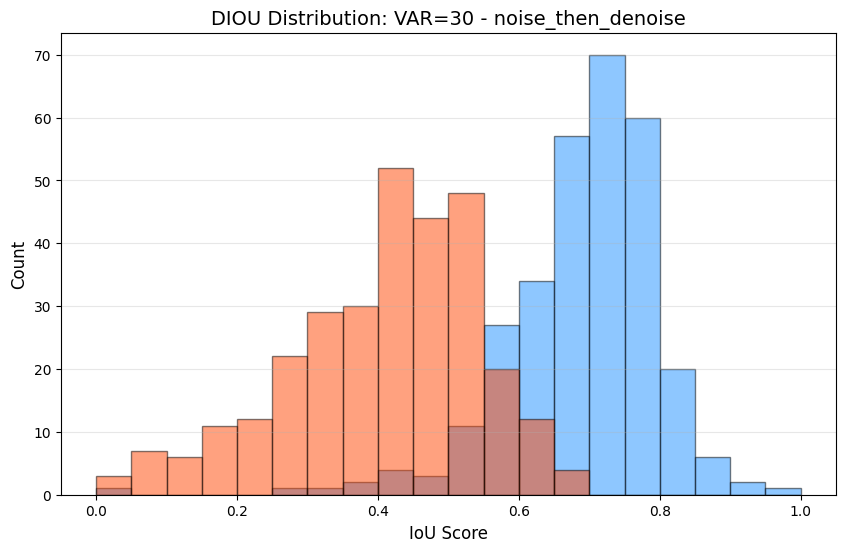

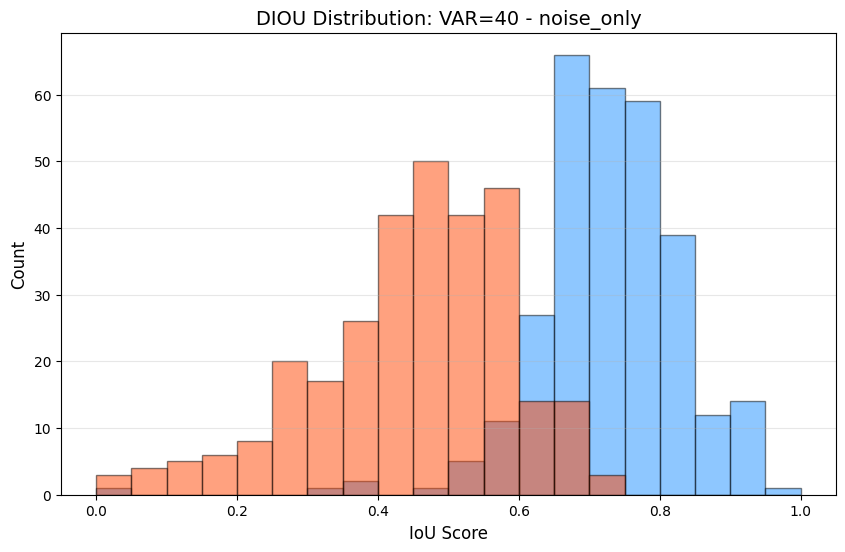

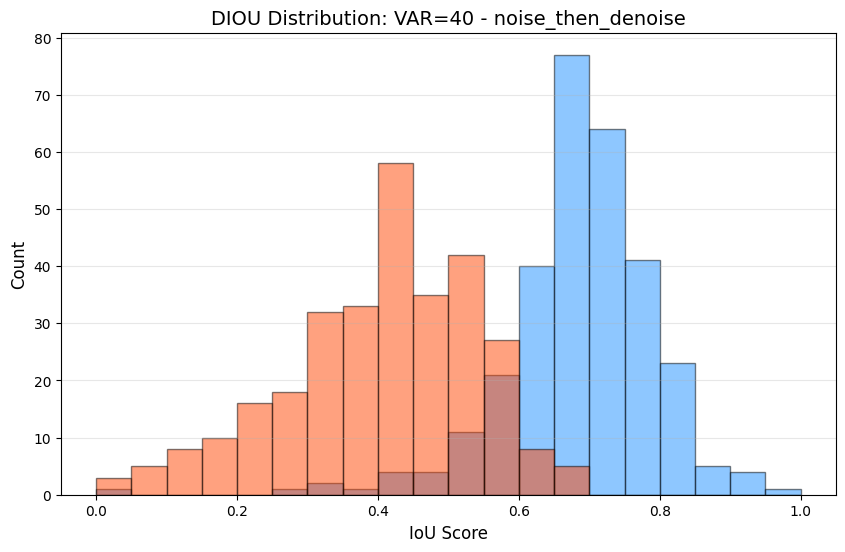

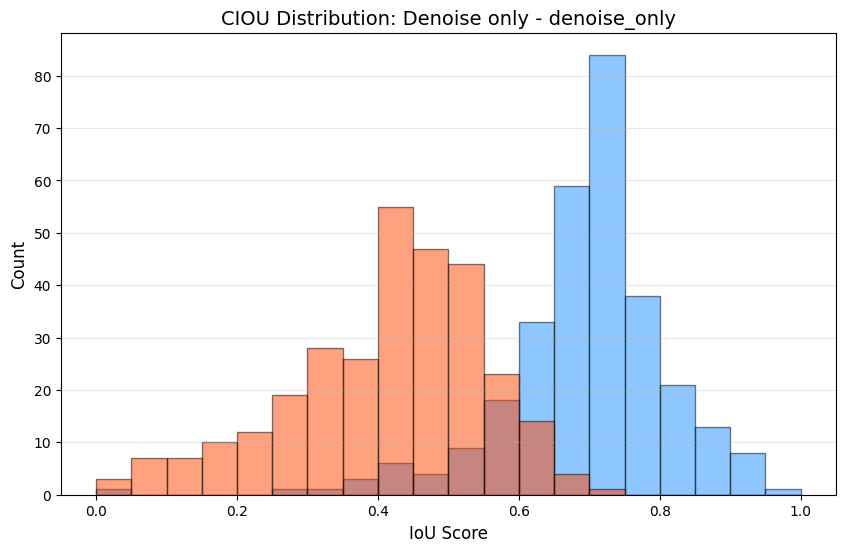

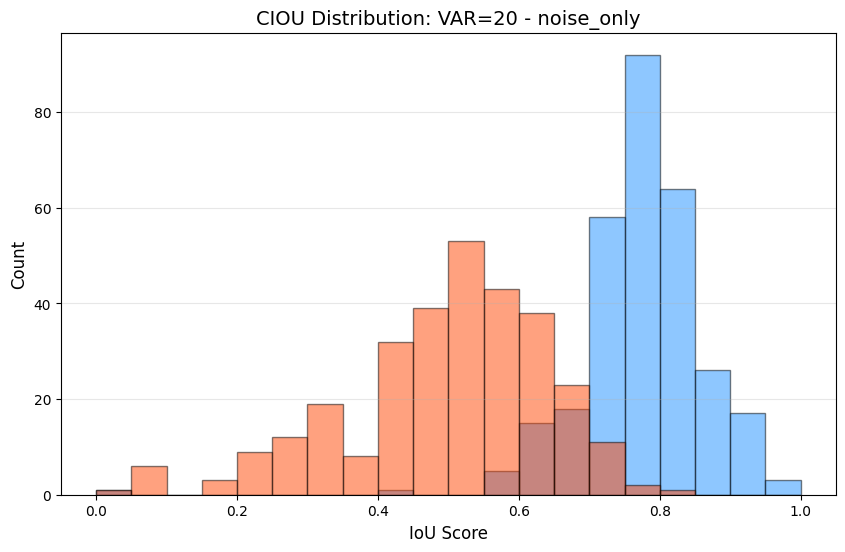

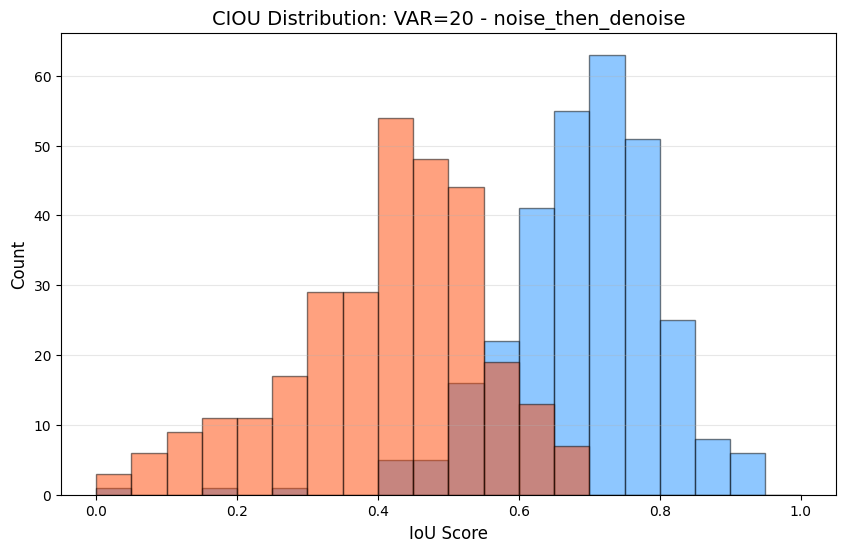

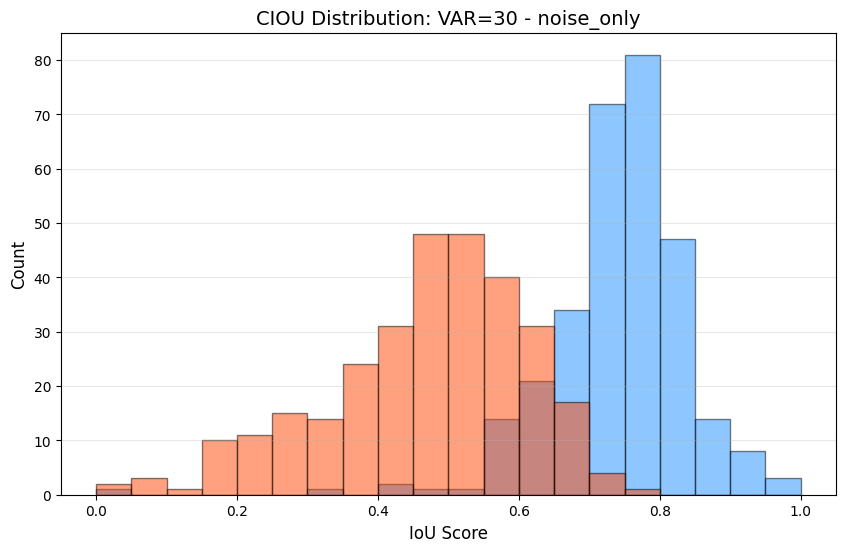

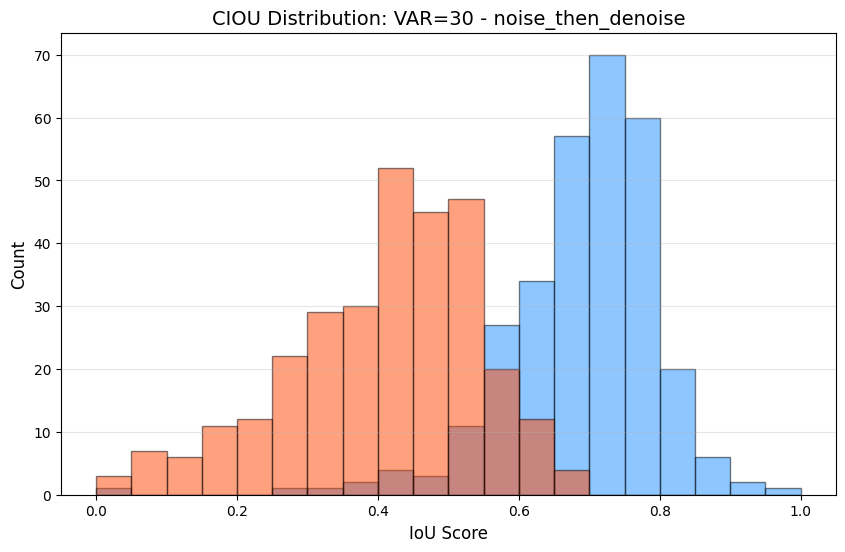

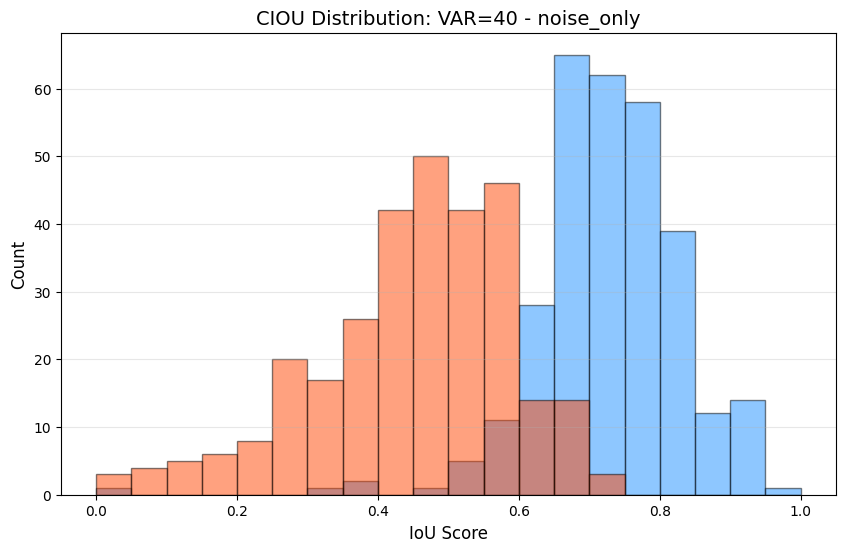

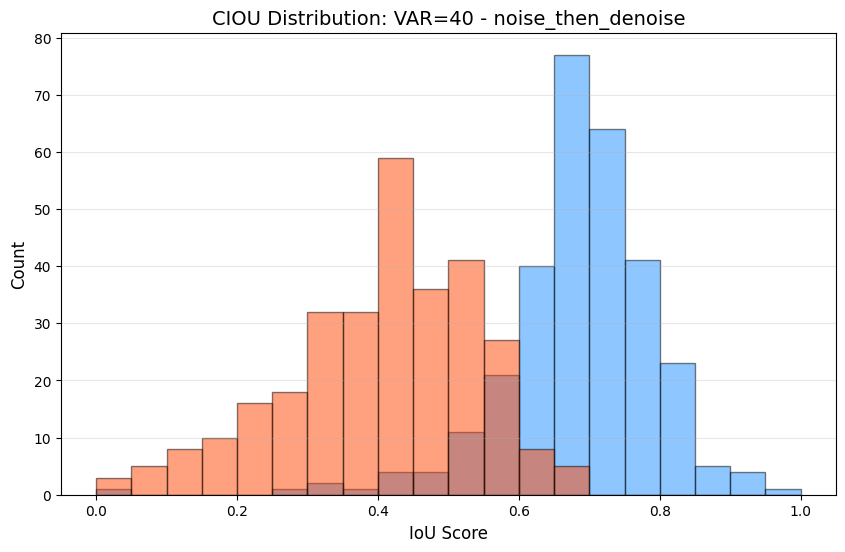

In [13]:
import math

iou_types = ["standard", "giou", "diou", "ciou"]
NUM_ITERATIONS = 5
CONFIDENCE_THRESHOLD = 0.5

# COMBINED: Put all noise configurations together to run in one batch test call
all_noise_configs = [
    # Poisson 
    {'type': 'poisson', 'scale': 0.1},
    {'type': 'poisson', 'scale': 0.3},
    {'type': 'poisson', 'scale': 0.9},
    
    # Gaussian
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(20)}, 
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(30)},
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(40)},
    
    # Salt and Pepper
    {'type': "salt_and_pepper", 'density': 0.01},
    {'type': "salt_and_pepper", 'density': 0.03},
    {'type': "salt_and_pepper", 'density': 0.06},
    
    # Speckle
    {'type': 'speckle', 'intensity': 0.05},
    {'type': 'speckle', 'intensity': 0.1},
    {'type': 'speckle', 'intensity': 0.4}
]

# Run the evaluation
batch_test_with_plots(
    num_iterations=NUM_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    test_images=test_images,
    target_class=TARGET_CLASS,
    noise_configs=all_noise_configs,
    iou_types=iou_types,
    denoiser=denoiser,
    pipelines=PIPELINES
)